In [1]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d,RegularGridInterpolator
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom
from matplotlib.colors import Normalize,LogNorm
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter1d
from sunpy.coordinates import Helioprojective, SphericalScreen, propagate_with_solar_surface
from astropy.wcs import WCS

__<font color=cyan>1.画movie 1</font>__

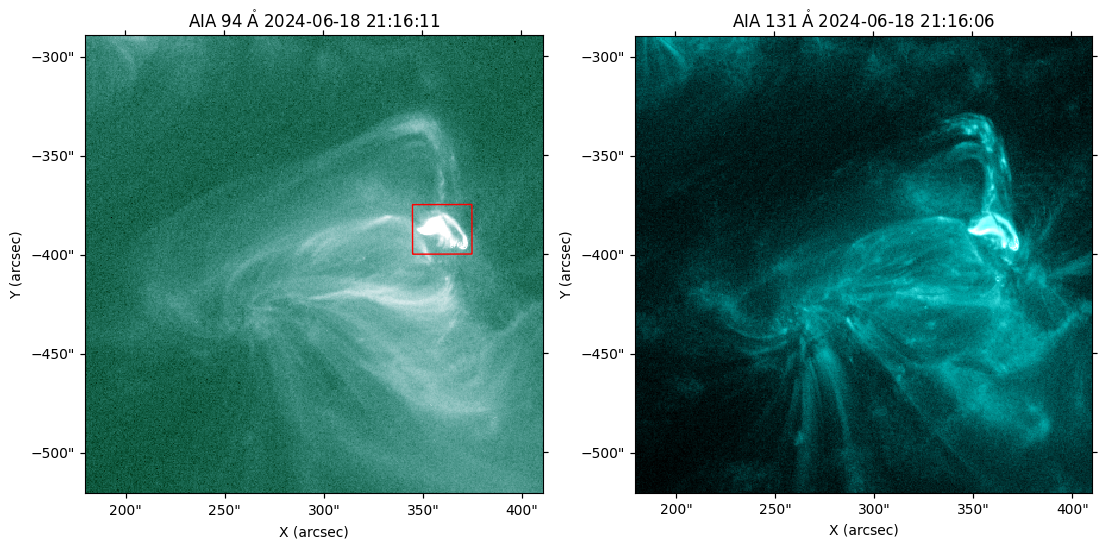

In [8]:
file_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\\'
file_list_94=glob.glob(file_path+'*94.*')
file_list_94.sort()
file_list_131=glob.glob(file_path+'*131.*')
file_list_131.sort()

i=321
map_94 = sunpy.map.Map(file_list_94[i])
map_131 = sunpy.map.Map(file_list_131[i])

bottom_left = SkyCoord(Tx=180*u.arcsec, Ty=-520*u.arcsec, frame=map_94.coordinate_frame)
top_right = SkyCoord(Tx=410*u.arcsec, Ty=-290*u.arcsec, frame=map_94.coordinate_frame)

smap_94 = map_94.submap(bottom_left, top_right=top_right)
smap_131 = map_131.submap(bottom_left, top_right=top_right)

fig = plt.figure(figsize=(13, 6))
ax1 = fig.add_subplot(1, 2, 1, projection=smap_94)
ax2 = fig.add_subplot(1, 2, 2, projection=smap_131)

norm_94 = smap_94.plot_settings['norm']
norm_94.vmax=300

norm_131 = smap_131.plot_settings['norm']
norm_131.vmin = 0.01
norm_131.vmax = 3000

smap_94.plot(axes=ax1, norm=norm_94)
smap_131.plot(axes=ax2, norm=norm_131)

bl2=SkyCoord(Tx=345*u.arcsec, Ty=-400*u.arcsec, frame=smap_94.coordinate_frame)
tr2=SkyCoord(Tx=375*u.arcsec, Ty=-375*u.arcsec, frame=smap_94.coordinate_frame)
smap_94.draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax1)

ax1.coords[0].grid(draw_grid=False)
ax1.coords[1].grid(draw_grid=False)
ax2.coords[0].grid(draw_grid=False)
ax2.coords[1].grid(draw_grid=False)
ax1.set_xlabel('X (arcsec)',labelpad=1.1)
ax1.set_ylabel('Y (arcsec)')
ax2.set_xlabel('X (arcsec)')
ax2.set_ylabel('Y (arcsec)')

In [3]:
#这一段代码是画视频1的，从20：22到21：40，左边94，右边131的视频
file_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\\'
file_list_94=glob.glob(file_path+'*94.*')
file_list_94.sort()
file_list_131=glob.glob(file_path+'*131.*')
file_list_131.sort()

output_path=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\.94_131fig_all\\'
ref_map_94=sunpy.map.Map(file_list_94[281])
ref_map_131=sunpy.map.Map(file_list_131[281])
bottom_left = SkyCoord(Tx=180*u.arcsec, Ty=-520*u.arcsec, frame=ref_map_94.coordinate_frame)
top_right = SkyCoord(Tx=410*u.arcsec, Ty=-290*u.arcsec, frame=ref_map_94.coordinate_frame)
ref_smap_94=ref_map_94.submap(bottom_left, top_right=top_right)
ref_smap_131=ref_map_131.submap(bottom_left, top_right=top_right)
for i in range(66,len(file_list_94),5):
    if i not in [241,281,291]:
        map_94 = sunpy.map.Map(file_list_94[i])
        map_131 = sunpy.map.Map(file_list_131[i])

        with propagate_with_solar_surface():
            rot_smap_94 = map_94.reproject_to(ref_smap_94.wcs, preserve_date_obs=True)
            rot_smap_131 = map_131.reproject_to(ref_smap_131.wcs, preserve_date_obs=True)
        
        fig = plt.figure(figsize=(13, 6))
        ax1 = fig.add_subplot(1, 2, 1, projection=rot_smap_94)
        ax2 = fig.add_subplot(1, 2, 2, projection=rot_smap_131)

        norm_94 = rot_smap_94.plot_settings['norm']
        norm_94.vmax=300

        norm_131 = rot_smap_131.plot_settings['norm']
        norm_131.vmin = 0.01
        norm_131.vmax = 1800

        rot_smap_94.plot(axes=ax1, norm=norm_94)
        rot_smap_131.plot(axes=ax2, norm=norm_131)
        ax1.coords[0].grid(draw_grid=False)
        ax1.coords[1].grid(draw_grid=False)
        ax2.coords[0].grid(draw_grid=False)
        ax2.coords[1].grid(draw_grid=False)
        ax1.set_xlabel('X (arcsec)',labelpad=1.1)
        ax1.set_ylabel('Y (arcsec)')
        ax2.set_xlabel('X (arcsec)')
        ax2.set_ylabel('Y (arcsec)')
        ax1.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax1.coords[1].set_major_formatter('s',show_decimal_unit=False)
        ax2.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax2.coords[1].set_major_formatter('s',show_decimal_unit=False)
        plt.savefig(output_path+f'{i:03d}.png', dpi=250)
        plt.close()

__<font color=cyan>2.画图1</font>__

In [2]:
#这里dir1是pre_131.sav的目录对应0-31，dir2是131.sav的目录对应32-132，exptime是长148的观测时间
def aia_intensity_curve(dir1,dir2,dir3,exptime,wavelenth):
    from scipy.io import readsav
    #这部分先把数据读入进来
    matrices=[]
    data1=readsav(dir1)
    matrix_struct=data1['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    matrices=matrices[69:]#这一步是当时我matrices统一设置成大小为110了，所以存的数据都在后面
    data2=readsav(dir2)
    matrix_struct=data2['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    data3=readsav(dir3)
    matrix_struct=data3['matrix_struct']
    for i,entry in enumerate(matrix_struct):
        matrix=entry['matrix']
        matrices.append(matrix)
    #计算平均强度
    intensity=np.zeros(148)
    for i in range(148):
        intensity[i]=np.average(matrices[i])
    #这里去掉曝光时间不一致的点，131和193单独处理
    if wavelenth=='131' or '193':
        threshold=2.90 if wavelenth=='131' else 1.99
        #print(threshold)
        intensity[exptime[:]<threshold]=np.nan
        #把去掉的点用插值函数补上
        x=np.arange(148)
        valid_x=x[~np.isnan(intensity)]
        valid_intensity=intensity[~np.isnan(intensity)]
        f=interp1d(valid_x,valid_intensity,kind='linear')
        intensity[np.isnan(intensity)]=f(x[np.isnan(intensity)])
    #归一化
    intensity=(intensity-np.min(intensity))/(np.max(intensity)-np.min(intensity))
    return intensity

In [3]:
intensity=np.zeros((7,148))
name_list=['.94','131','171','193','211','304','335']

for i in range(7):
    path=os.path.join(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2',name_list[i],'*.fits')
    file_list=glob.glob(path)
    exptime=np.zeros(len(file_list))
    for j in range(len(file_list)):
        rsm=fits.open(file_list[j])
        exptime[j]=rsm[1].header['EXPTIME']

    dir1=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\pre_'+name_list[i]+'.sav'
    dir2=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\\'+name_list[i]+'.sav'
    dir3=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\post_'+name_list[i]+'.sav'
    intensity[i,:]=aia_intensity_curve(dir1,dir2,dir3,exptime[:],name_list[i])
    #print(exptime[:133])

In [6]:
map1=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T204301Z.94.image_lev1.fits')
map2=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T211813Z.94.image_lev1.fits')
map3=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\20240618_2000_2230\aia.lev1_euv_12s.2024-06-18T213913Z.94.image_lev1.fits')
map4=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\HMI_generate_Bxyz_r\Br_map.fits')
map5=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211644Z.131.image_lev1.fits')
map6=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211820Z.131.image_lev1.fits')
map7=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T212244Z.131.image_lev1.fits')
map8=sunpy.map.Map(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\171\aia.lev1_euv_12s.2024-06-18T211822Z.171.image_lev1.fits')

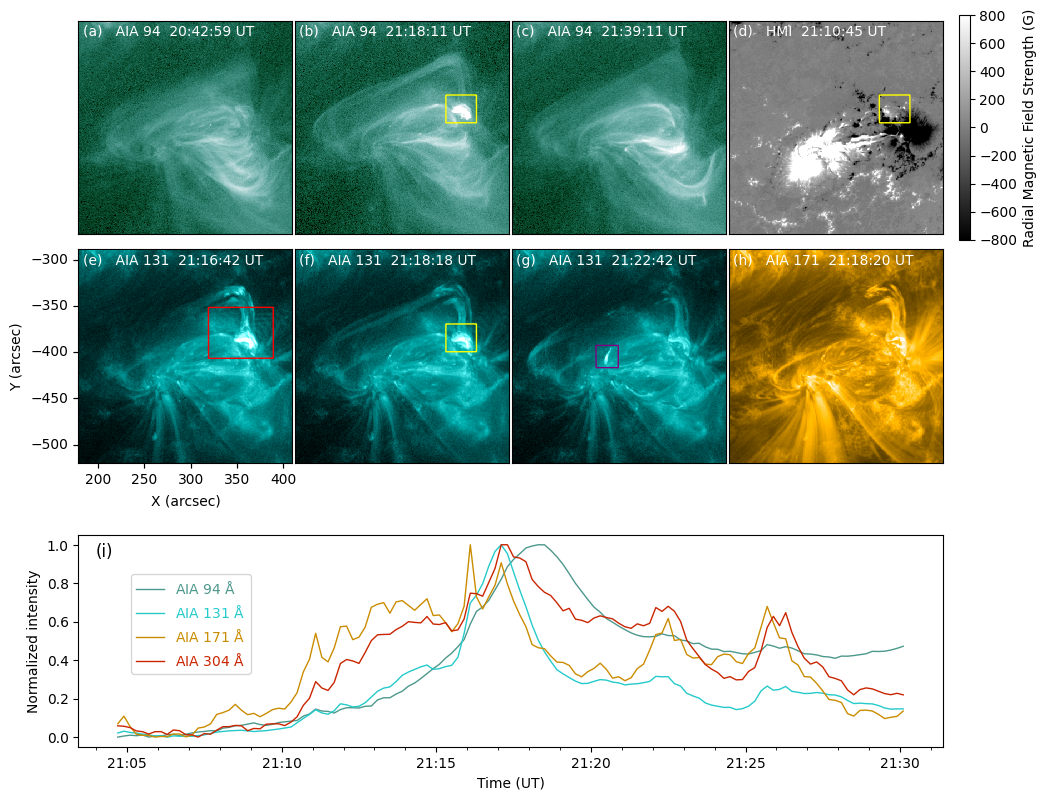

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11.5,9.5))

# 整体划分为上下两大块：上(3份高度)，下(2份高度)
gs = gridspec.GridSpec(2, 1, height_ratios=[7.5, 3.5], hspace=0.2)

# ---------------- 上半部分：AIA 三幅图 ----------------
# 这里再细分成 1 行 3 列的小网格
gs_top = gridspec.GridSpecFromSubplotSpec(2, 6, subplot_spec=gs[0], wspace=0.02,hspace=0.02,width_ratios=[1,1,1,1,0.05,0.05])
bottom_left=SkyCoord(Tx=180*u.arcsec,Ty=-520*u.arcsec,frame=map1.coordinate_frame)
top_right=SkyCoord(Tx=410*u.arcsec,Ty=-290*u.arcsec,frame=map1.coordinate_frame)
#这个标记IRIS观测区域的具体位置，在process_iris.pro文档里有写，导出的矩阵所处的Tx=[320,390]Ty=[-462,-352]范围
#之后读取all_sji_image.sav的时候有一步[330:,:]，把y轴方向裁剪掉了一半，所以现在ty=[-407,-352]
bl2=SkyCoord(Tx=320*u.arcsec, Ty=-407*u.arcsec, frame=map1.coordinate_frame)
tr2=SkyCoord(Tx=390*u.arcsec, Ty=-352*u.arcsec, frame=map1.coordinate_frame)

map_all=[map1,map2,map3,map4,map5,map6,map7,map8]
smap_all=[]
for i in map_all:
    smap_all.append(i.submap(bottom_left,top_right=top_right))

#对94去除较差自转
with propagate_with_solar_surface():
    for i in range(8):
        if i!=1:
            smap_all[i]=map_all[i].reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[0]=map1.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
    # smap_all[2]=map3.reproject_to(smap_all[1].wcs,preserve_date_obs=True)

ax_all=[]
for i in range(8):
    r=i//4
    c=i%4
    ax=fig.add_subplot(gs_top[r,c],projection=smap_all[i])
    #ax=fig.add_subplot(gs_top[i],projection=smap_all[i])
    ax_all.append(ax)
    if i==7:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=5000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==0 or i==1 or i==2:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=300
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==4 or i==5 or i==6:
        old_norm=smap_all[i].plot_settings['norm']
        old_norm.vmin=0.01
        old_norm.vmax=2000
        smap_all[i].plot(axes=ax,norm=old_norm)
    elif i==3:
        im_hmi=smap_all[i].plot(axes=ax_all[i])
        im_hmi.set_clim(-800,800)
    
    ax.set_title('')
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    #第5张图加X Y轴
    if i == 4:   # 左下角
        #标出IRIS的位置
        smap_all[i].draw_quadrangle(bl2,top_right=tr2,edgecolor='red',axes=ax)
        #非常搞，如果不加这个labelpad就会在x轴上方出现一条小缝
        ax.set_xlabel('X (arcsec)')
        #ax.set_xlabel('X(arcsecs)',labelpad=1.1)
        ax.set_ylabel('Y (arcsec)')
        ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
        ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False)
        #关掉单位
        ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
        ax.coords[1].set_major_formatter('s',show_decimal_unit=False) 
      
    else:
        ax.coords[0].set_ticklabel_visible(False)
        ax.coords[1].set_ticklabel_visible(False)
        ax.coords[0].set_ticks_visible(False)
        ax.coords[1].set_ticks_visible(False)

cax_d=fig.add_subplot(gs_top[0,5])
cbar_d=fig.colorbar(im_hmi,cax=cax_d)
cbar_d.set_label('Radial Magnetic Field Strength (G)')

bl3=SkyCoord(Tx=342*u.arcsec,Ty=-400*u.arcsec,frame=smap_all[3].coordinate_frame)
tr3=SkyCoord(Tx=375*u.arcsec,Ty=-370*u.arcsec,frame=smap_all[3].coordinate_frame)
smap_all[1].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[1])
smap_all[3].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[3])
smap_all[5].draw_quadrangle(bl3,top_right=tr3,edgecolor='yellow',axes=ax_all[5])

bl4=SkyCoord(Tx=270*u.arcsec,Ty=-417*u.arcsec,frame=smap_all[4].coordinate_frame)
tr4=SkyCoord(Tx=294*u.arcsec,Ty=-393*u.arcsec,frame=smap_all[4].coordinate_frame)
smap_all[6].draw_quadrangle(bl4,top_right=tr4,edgecolor='purple',axes=ax_all[6])

ax_all[0].text(0.02,0.93,'(a)   AIA 94  20:42:59 UT',color='white',transform=ax_all[0].transAxes,fontsize=10)
ax_all[1].text(0.02,0.93,'(b)   AIA 94  21:18:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=10)
ax_all[2].text(0.02,0.93,'(c)   AIA 94  21:39:11 UT',color='white',transform=ax_all[2].transAxes,fontsize=10)
ax_all[3].text(0.02,0.93,'(d)   HMI  21:10:45 UT',color='white',transform=ax_all[3].transAxes,fontsize=10)
ax_all[4].text(0.02,0.93,'(e)   AIA 131  21:16:42 UT',color='white',transform=ax_all[4].transAxes,fontsize=10)
ax_all[5].text(0.02,0.93,'(f)   AIA 131  21:18:18 UT',color='white',transform=ax_all[5].transAxes,fontsize=10)
ax_all[6].text(0.02,0.93,'(g)   AIA 131  21:22:42 UT',color='white',transform=ax_all[6].transAxes,fontsize=10)
ax_all[7].text(0.02,0.93,'(h)   AIA 171  21:18:20 UT',color='white',transform=ax_all[7].transAxes,fontsize=10)
# ---------------- 下半部分 ----------------
gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 6, subplot_spec=gs[1], wspace=0.02, hspace=0.05,
                                             width_ratios=[1,1,1,1,0.05,0.05])

ax8 = fig.add_subplot(gs_bottom[0,0:4])

name_list=[r'AIA 94 $\mathrm{\AA}$',r'AIA 131 $\mathrm{\AA}$',
           r'AIA 171 $\mathrm{\AA}$',r'AIA 193 $\mathrm{\AA}$',
           r'AIA 211 $\mathrm{\AA}$',r'AIA 304 $\mathrm{\AA}$',r'AIA 335 $\mathrm{\AA}$']
lines=[]
linstyle=['-','-']

#从AIA那几个波段的cmap里采集颜色用来画曲线
color=[]
color_list=['sdoaia94','sdoaia131','sdoaia171','sdoaia193','sdoaia211','sdoaia304','sdoaia335']
for i in range(7):
    cmap=plt.get_cmap(color_list[i])
    middle_color=cmap(0.55)
    color.append(middle_color)
#画七条AIA曲线
for i in range(7):
    if i==1 or i==2 or i==0 or i==5:
        line,=ax8.plot(intensity[i,20:],color=color[i],label=name_list[i],linewidth=1,linestyle=linstyle[i%2])
        lines.append(line)
legend=ax8.legend(loc='center', bbox_to_anchor=(0.13, 0.58),fontsize=10)
#让legend里的文字颜色和曲线颜色一致
for text,line in zip(legend.get_texts(),lines):
    text.set_color(line.get_color())

corr_x=np.zeros(6)
#第一个时刻对应21：00：42，最后一个时刻对应21：27：06
for i in range(len(corr_x)):
    corr_x[i]=(i*300+18)/12
ax8.set_ylabel('Normalized intensity')
ax8.set_xticks(ticks=corr_x,labels=['21:05','21:10','21:15','21:20','21:25','21:30'])
ax8.text(0.02,0.9,'(i)',color='black',transform=ax8.transAxes,fontsize=12)
import matplotlib.ticker as ticker
ax8.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax8.yaxis.set_minor_locator(ticker.NullLocator())       # 禁止 y 轴小刻度
ax8.set_xlabel('Time (UT)')
plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\aia_image_intensity_curve.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

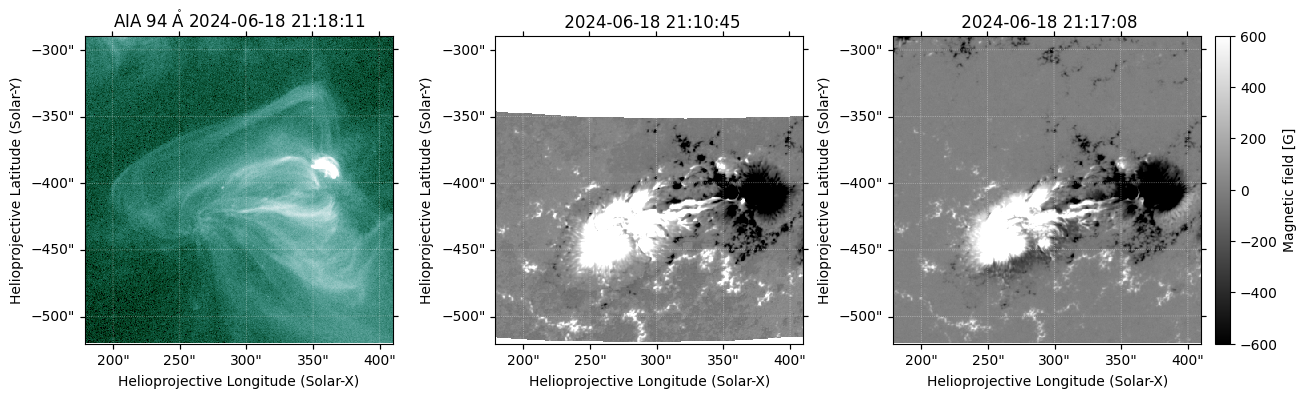

In [7]:
br_map=sunpy.map.Map(r'C:\Users\xiao\Downloads\JSOC_20260313_002510\hmi.sharp_cea_720s.11376.20240618_211200_TAI.Br.fits')
br_map_remap=br_map.reproject_to(smap_all[1].wcs,preserve_date_obs=True)
fig = plt.figure(figsize=(15,4))
ax1=fig.add_subplot(1,3,1, projection=smap_all[1])
im1=smap_all[1].plot(axes=ax1)
ax2 = fig.add_subplot(1,3,2, projection=br_map_remap)
im2=br_map_remap.plot(axes=ax2)
im2.set_clim(-600,600)
# cbar2 = fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
# cbar2.set_label('Magnetic field [G]')
ax3=fig.add_subplot(1,3,3, projection=smap_all[3])
im3=smap_all[3].plot(axes=ax3)
im3.set_clim(-600,600)
cbar3 = fig.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
cbar3.set_label('Magnetic field [G]')

<font color=cyan>检查这个T和EM随时间变化的图，123三个框位置选择的合理性</font>  
现在决定是不放了，b图单独拿出来放在DEM的图里面

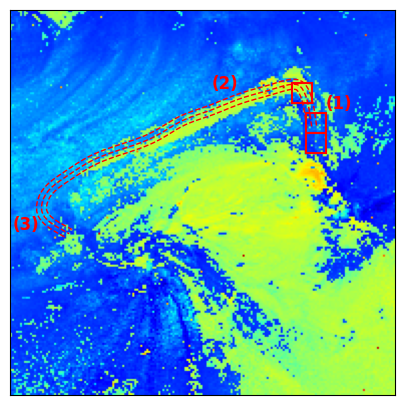

In [61]:
data=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

time_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros((58,3))
avg_em=np.zeros((58,3))
for i in range(58):
    datas=readsav(file_list[i*2])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]

    #avg_temp[i,0]=np.mean(smap_temp[140:150,142:152])
    avg_temp[i,0]=np.mean(smap_temp[145:155,140:150])
    avg_temp[i,1]=np.mean(smap_temp[138:148,102:112])
    avg_temp[i,2]=np.mean(smap_temp[80:90,15:25])
    
    #avg_em[i,0]=np.mean(smap_em[140:150,142:152])
    avg_em[i,0]=np.mean(smap_em[145:155,140:150])
    avg_em[i,1]=np.mean(smap_em[138:148,102:112])
    avg_em[i,2]=np.mean(smap_em[80:90,15:25])

fig,ax=plt.subplots(figsize=(5,5))
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
ax.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')

left_bottom1=(140,145)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)

ax.add_patch(rect1)

left_bottom2=(147,130)
rect2=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
left_bottom3=(147,120)
rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax.add_patch(rect2)
ax.add_patch(rect3)
ax.set_xticks([])
ax.set_yticks([])
ax.text(157,142,'(1)',color='red',fontsize=12,fontweight='bold')
ax.text(100,152,'(2)',color='red',fontsize=12,fontweight='bold')
ax.text(1,82,'(3)',color='red',fontsize=12,fontweight='bold')

ax.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)


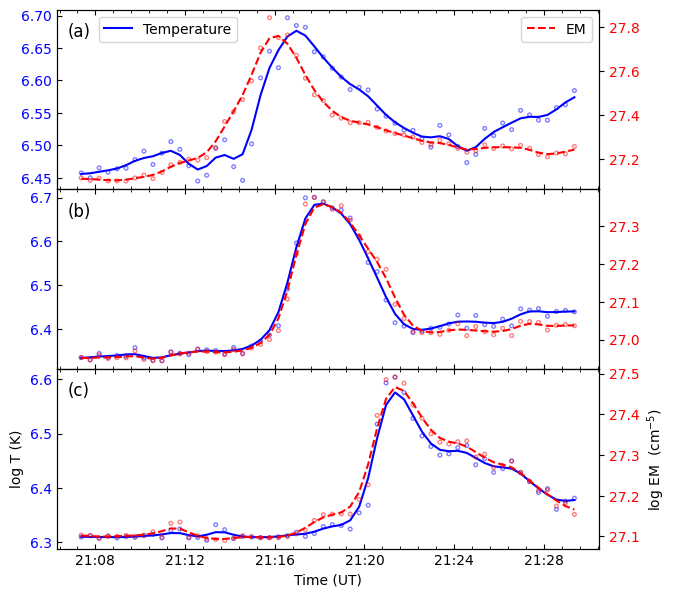

In [3]:
logT=np.log10(avg_temp)
logem=np.log10(avg_em)
#xrange=np.linspace(0,54,28)
fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1],'hspace': 0})
data1=logT[:56,0]
sigma=1.2
alpha=0.5
smoothed_data1=gaussian_filter1d(data1,sigma=sigma)
ax1.plot(np.linspace(0,55,56),smoothed_data1,label='Temperature',color='blue')
ax1.scatter(np.linspace(0,55,56),logT[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(a)',color='black',transform=ax1.transAxes,fontsize=12)
ax11=ax1.twinx()
data11=logem[:56,0]
smoothed_data11=gaussian_filter1d(data11,sigma=sigma)
ax11.plot(np.linspace(0,55,56),smoothed_data11,label='EM',linestyle='--',color='red')
ax11.scatter(np.linspace(0,55,56),logem[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax11.tick_params(axis='y',labelcolor='red')
coor_x=np.zeros(6)
for i in range(len(coor_x)):
    coor_x[i]=(i*240+38)/24
label_x=['21:08','21:12','21:16','21:20','21:24','21:28']
ax1.set_xticks(ticks=coor_x,labels=label_x)
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())
ax1.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax11.legend(loc='upper right')

data2=logT[:56,1]
smoothed_data2=gaussian_filter1d(data2,sigma=sigma)
ax2.plot(np.linspace(0,55,56),smoothed_data2,label='Temperature',color='blue')
ax2.scatter(np.linspace(0,55,56),logT[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(b)',color='black',transform=ax2.transAxes,fontsize=12)
ax22=ax2.twinx()
data22=logem[:56,1]
smoothed_data22=gaussian_filter1d(data22,sigma=sigma)
ax22.plot(np.linspace(0,55,56),smoothed_data22,label='EM',linestyle='--',color='red')
ax22.scatter(np.linspace(0,55,56),logem[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax22.tick_params(axis='y',labelcolor='red')

data3=logT[:56,2]
smoothed_data3=gaussian_filter1d(data3,sigma=sigma)
ax3.plot(np.linspace(0,55,56),smoothed_data3,label='Temperature',color='blue')
ax3.scatter(np.linspace(0,55,56),logT[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax3.set_ylabel('log T (K)')
ax3.set_xlabel('Time (UT)')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(c)',color='black',transform=ax3.transAxes,fontsize=12)
ax33=ax3.twinx()
data33=logem[:56,2]
smoothed_data33=gaussian_filter1d(data33,sigma=sigma)
ax33.plot(np.linspace(0,55,56),smoothed_data33,label='EM 3',linestyle='--',color='red')
ax33.scatter(np.linspace(0,55,56),logem[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax33.set_ylabel('log EM  '+ r'$(\text{cm}^{-5})$')

ax33.tick_params(axis='y',labelcolor='red')

for ax in [ax1,ax2]:
    ax.label_outer()#去掉上两个的xlabel xticklabel

for ax in [ax1,ax2,ax3]:
    ax.tick_params(axis='x',which='both',direction='in',top='True')
    ax.tick_params(axis='y',which='both',direction='in')
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig4\T_DEM_time2.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)


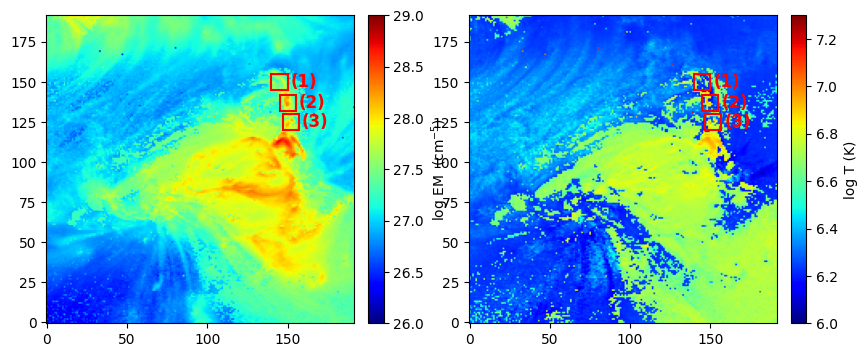

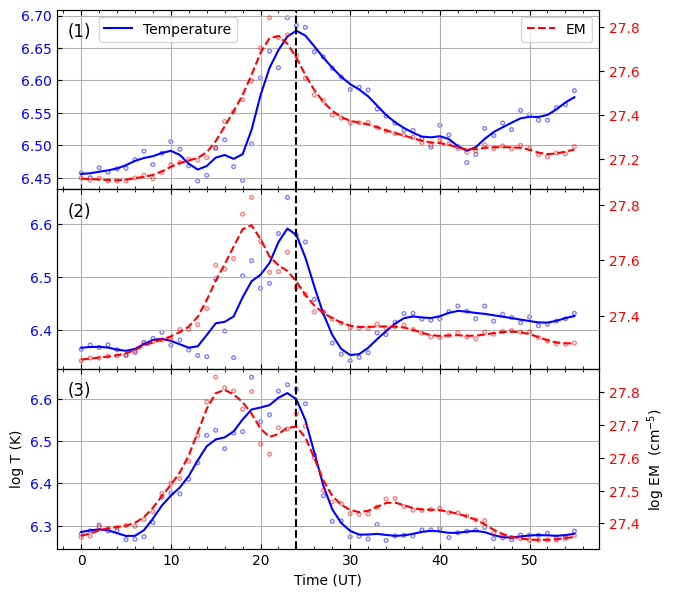

In [54]:
time_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros((58,3))
avg_em=np.zeros((58,3))
x1,y1=140,145
x2,y2=145,132
x3,y3=147,120
for i in range(58):
    datas=readsav(file_list[i*2])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]

    #avg_temp[i,0]=np.mean(smap_temp[140:150,142:152])
    avg_temp[i,0]=np.mean(smap_temp[y1:y1+10,x1:x1+10])
    avg_temp[i,1]=np.mean(smap_temp[y2:y2+10,x2:x2+10])
    avg_temp[i,2]=np.mean(smap_temp[y3:y3+10,x3:x3+10])
    avg_em[i,0]=np.mean(smap_em[y1:y1+10,x1:x1+10])
    avg_em[i,1]=np.mean(smap_em[y2:y2+10,x2:x2+10])
    avg_em[i,2]=np.mean(smap_em[y3:y3+10,x3:x3+10])
logT=np.log10(avg_temp)
logem=np.log10(avg_em)

fig,(ax00,ax0)=plt.subplots(1,2,figsize=(10,4))
datas=readsav(file_list[38])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im2=ax00.imshow(np.log10(smap_em),vmin=26.0,vmax=29.0,cmap='jet',origin='lower')
fig.colorbar(im2, ax=ax00, fraction=0.046, pad=0.04).set_label('log EM  '+ r'$(\text{cm}^{-5})$')
im1=ax0.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')

fig.colorbar(im1, ax=ax0, fraction=0.046, pad=0.04).set_label('log T (K)')


for ax in [ax00,ax0]:
    left_bottom1=(x1,y1)
    rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom2=(x2,y2)
    rect2=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom3=(x3,y3)
    rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)

    ax.text(x1+12,y1+2,'(1)',color='red',fontsize=12,fontweight='bold')
    ax.text(x2+12,y2+2,'(2)',color='red',fontsize=12,fontweight='bold')
    ax.text(x3+12,y3+2,'(3)',color='red',fontsize=12,fontweight='bold')


fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1],'hspace': 0})
data1=logT[:56,0]
sigma=1.2
alpha=0.5
smoothed_data1=gaussian_filter1d(data1,sigma=sigma)
ax1.plot(np.linspace(0,55,56),smoothed_data1,label='Temperature',color='blue')
ax1.scatter(np.linspace(0,55,56),logT[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(1)',color='black',transform=ax1.transAxes,fontsize=12)
ax1.axvline(x=24,color='black',linestyle='--')
ax1.grid(True)
ax11=ax1.twinx()
data11=logem[:56,0]
smoothed_data11=gaussian_filter1d(data11,sigma=sigma)
ax11.plot(np.linspace(0,55,56),smoothed_data11,label='EM',linestyle='--',color='red')
ax11.scatter(np.linspace(0,55,56),logem[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax11.tick_params(axis='y',labelcolor='red')

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())
ax1.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax11.legend(loc='upper right')

data2=logT[:56,1]
smoothed_data2=gaussian_filter1d(data2,sigma=sigma)
ax2.plot(np.linspace(0,55,56),smoothed_data2,label='Temperature',color='blue')
ax2.scatter(np.linspace(0,55,56),logT[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(2)',color='black',transform=ax2.transAxes,fontsize=12)
ax2.axvline(x=24,color='black',linestyle='--')
ax2.grid(True)
ax22=ax2.twinx()
data22=logem[:56,1]
smoothed_data22=gaussian_filter1d(data22,sigma=sigma)
ax22.plot(np.linspace(0,55,56),smoothed_data22,label='EM',linestyle='--',color='red')
ax22.scatter(np.linspace(0,55,56),logem[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax22.tick_params(axis='y',labelcolor='red')

data3=logT[:56,2]
smoothed_data3=gaussian_filter1d(data3,sigma=sigma)
ax3.plot(np.linspace(0,55,56),smoothed_data3,label='Temperature',color='blue')
ax3.scatter(np.linspace(0,55,56),logT[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax3.set_ylabel('log T (K)')
ax3.set_xlabel('Time (UT)')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(3)',color='black',transform=ax3.transAxes,fontsize=12)
ax3.axvline(x=24,color='black',linestyle='--')
ax3.grid(True)
ax33=ax3.twinx()
data33=logem[:56,2]
smoothed_data33=gaussian_filter1d(data33,sigma=sigma)
ax33.plot(np.linspace(0,55,56),smoothed_data33,label='EM 3',linestyle='--',color='red')
ax33.scatter(np.linspace(0,55,56),logem[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax33.set_ylabel('log EM  '+ r'$(\text{cm}^{-5})$')

ax33.tick_params(axis='y',labelcolor='red')

for ax in [ax1,ax2]:
    ax.label_outer()#去掉上两个的xlabel xticklabel

for ax in [ax1,ax2,ax3]:
    ax.tick_params(axis='x',which='both',direction='in',top='True')
    ax.tick_params(axis='y',which='both',direction='in')
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig4\T_DEM_time2.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)


In [60]:
for i in range(58):
    fig,[ax00,ax0]=plt.subplots(1,2,figsize=(30,12))
    datas=readsav(file_list[i*2])
    result=datas['result']
    dem_out=result['DEM_OUT'][0]
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]
    im2=ax00.imshow(np.log10(smap_em),vmin=26.0,vmax=29.0,cmap='jet',origin='lower')
    cbar2=fig.colorbar(im2, ax=ax00, fraction=0.046, pad=0.04)
    cbar2.set_label('log EM  '+ r'$(\text{cm}^{-5})$',fontsize=24)
    cbar2.ax.tick_params(labelsize=24)
    im1=ax0.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
    
    cbar1=fig.colorbar(im1, ax=ax0, fraction=0.046, pad=0.04)
    cbar1.set_label('log T (K)',fontsize=24)
    cbar1.ax.tick_params(labelsize=24)
    
    ax00.set_title(str(i),fontsize=24)
    #ax00.set_title('Emission Measure',fontsize=24)
    width=10
    height=10

    for ax in [ax00,ax0]:
        left_bottom1=(x1,y1)
        rect1=Rectangle(left_bottom1,width,height,edgecolor='red',facecolor='none',linewidth=4)
        left_bottom2=(x2,y2)
        rect2=Rectangle(left_bottom2,width,height,edgecolor='red',facecolor='none',linewidth=4)
        left_bottom3=(x3,y3)
        rect3=Rectangle(left_bottom3,15,15,edgecolor='red',facecolor='none',linewidth=4)
        ax.add_patch(rect1)
        ax.add_patch(rect2)
        ax.add_patch(rect3)

        ax.text(x1+12,y1+2,'(1)',color='red',fontsize=24,fontweight='bold')
        ax.text(x2-15,y2+2,'(3)',color='red',fontsize=24,fontweight='bold')
        ax.text(x3+12,y3+2,'(4)',color='red',fontsize=24,fontweight='bold')
    plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM_test2\\'+str(i).zfill(2)+'.png')
    plt.close()

C:\Users\xiao\AppData\Local\Temp\ipykernel_11152\1555526909.py:8: RuntimeWarning: invalid value encountered in log10
  im2=ax00.imshow(np.log10(smap_em),vmin=26.0,vmax=29.0,cmap='jet',origin='lower')


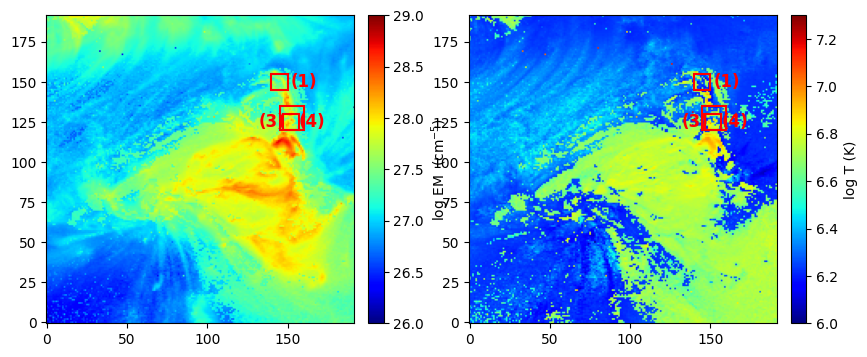

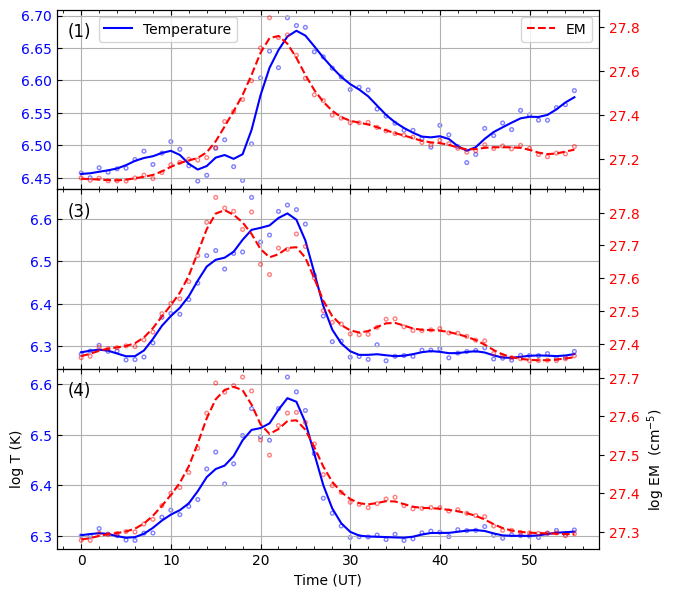

In [58]:
time_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\\'+'*.fits')
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
avg_temp=np.zeros((58,3))
avg_em=np.zeros((58,3))
x1,y1=140,145
x2,y2=147,120
x3,y3=145,120
height=10
width=10
for i in range(58):
    datas=readsav(file_list[i*2])
    result=datas['result']
    smap_temp=result['SMAP_TEMP'][0]
    smap_em=result['SMAP_EM'][0]

    #avg_temp[i,0]=np.mean(smap_temp[140:150,142:152])
    avg_temp[i,0]=np.mean(smap_temp[y1:y1+height,x1:x1+width])
    avg_temp[i,1]=np.mean(smap_temp[y2:y2+height,x2:x2+width])
    avg_temp[i,2]=np.mean(smap_temp[y3:y3+15,x3:x3+15])
    avg_em[i,0]=np.mean(smap_em[y1:y1+height,x1:x1+width])
    avg_em[i,1]=np.mean(smap_em[y2:y2+height,x2:x2+width])
    avg_em[i,2]=np.mean(smap_em[y3:y3+15,x3:x3+15])
logT=np.log10(avg_temp)
logem=np.log10(avg_em)

fig,(ax00,ax0)=plt.subplots(1,2,figsize=(10,4))
datas=readsav(file_list[38])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im2=ax00.imshow(np.log10(smap_em),vmin=26.0,vmax=29.0,cmap='jet',origin='lower')
fig.colorbar(im2, ax=ax00, fraction=0.046, pad=0.04).set_label('log EM  '+ r'$(\text{cm}^{-5})$')
im1=ax0.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')

fig.colorbar(im1, ax=ax0, fraction=0.046, pad=0.04).set_label('log T (K)')


for ax in [ax00,ax0]:
    left_bottom1=(x1,y1)
    rect1=Rectangle(left_bottom1,width,height,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom2=(x2,y2)
    rect2=Rectangle(left_bottom2,width,height,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom3=(x3,y3)
    rect3=Rectangle(left_bottom3,15,15,edgecolor='red',facecolor='none',linewidth=1.5)
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)

    ax.text(x1+12,y1+2,'(1)',color='red',fontsize=12,fontweight='bold')
    ax.text(x2-15,y2+2,'(3)',color='red',fontsize=12,fontweight='bold')
    ax.text(x3+12,y3+2,'(4)',color='red',fontsize=12,fontweight='bold')



fig,(ax1,ax2,ax3)=plt.subplots(3,1,figsize=(7,7),sharex=True,
                               gridspec_kw={'height_ratios': [1, 1, 1],'hspace': 0})
data1=logT[:56,0]
sigma=1.2
alpha=0.5
smoothed_data1=gaussian_filter1d(data1,sigma=sigma)
ax1.plot(np.linspace(0,55,56),smoothed_data1,label='Temperature',color='blue')
ax1.scatter(np.linspace(0,55,56),logT[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax1.tick_params(axis='y',labelcolor='blue')
ax1.text(0.02,0.85,'(1)',color='black',transform=ax1.transAxes,fontsize=12)
ax1.grid(True)
ax11=ax1.twinx()
data11=logem[:56,0]
smoothed_data11=gaussian_filter1d(data11,sigma=sigma)
ax11.plot(np.linspace(0,55,56),smoothed_data11,label='EM',linestyle='--',color='red')
ax11.scatter(np.linspace(0,55,56),logem[:56,0],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax11.tick_params(axis='y',labelcolor='red')

ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())  # 给 x 轴加小刻度
ax1.yaxis.set_minor_locator(ticker.NullLocator())
ax1.legend(loc='upper left',bbox_to_anchor=(0.065,1))
ax11.legend(loc='upper right')

data2=logT[:56,1]
smoothed_data2=gaussian_filter1d(data2,sigma=sigma)
ax2.plot(np.linspace(0,55,56),smoothed_data2,label='Temperature',color='blue')
ax2.scatter(np.linspace(0,55,56),logT[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax2.tick_params(axis='y',labelcolor='blue')
ax2.text(0.02,0.85,'(3)',color='black',transform=ax2.transAxes,fontsize=12)
ax2.grid(True)
ax22=ax2.twinx()
data22=logem[:56,1]
smoothed_data22=gaussian_filter1d(data22,sigma=sigma)
ax22.plot(np.linspace(0,55,56),smoothed_data22,label='EM',linestyle='--',color='red')
ax22.scatter(np.linspace(0,55,56),logem[:56,1],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax22.tick_params(axis='y',labelcolor='red')

data3=logT[:56,2]
smoothed_data3=gaussian_filter1d(data3,sigma=sigma)
ax3.plot(np.linspace(0,55,56),smoothed_data3,label='Temperature',color='blue')
ax3.scatter(np.linspace(0,55,56),logT[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='blue')
ax3.set_ylabel('log T (K)')
ax3.set_xlabel('Time (UT)')
ax3.tick_params(axis='y',labelcolor='blue')
ax3.text(0.02,0.85,'(4)',color='black',transform=ax3.transAxes,fontsize=12)
ax3.grid(True)
ax33=ax3.twinx()
data33=logem[:56,2]
smoothed_data33=gaussian_filter1d(data33,sigma=sigma)
ax33.plot(np.linspace(0,55,56),smoothed_data33,label='EM 3',linestyle='--',color='red')
ax33.scatter(np.linspace(0,55,56),logem[:56,2],alpha=alpha,s=7,facecolor='none',edgecolor='red')
ax33.set_ylabel('log EM  '+ r'$(\text{cm}^{-5})$')

ax33.tick_params(axis='y',labelcolor='red')

for ax in [ax1,ax2]:
    ax.label_outer()#去掉上两个的xlabel xticklabel

for ax in [ax1,ax2,ax3]:
    ax.tick_params(axis='x',which='both',direction='in',top='True')
    ax.tick_params(axis='y',which='both',direction='in')
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig4\T_DEM_time2.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)


<font color=cyan>画DEM图</font>

5.149874071052627 4.8910559440820895 4.632244169727517
4.891058061620744
离太阳的距离是 151963569604.3406 m
一角秒对应多少千米是 736.7401757413695 km/arc
分辨率是 0.600697994 arc/pixel
尺寸是 2164.5785643123554 km/pixel
168.83712801636375
2.1645785643123556


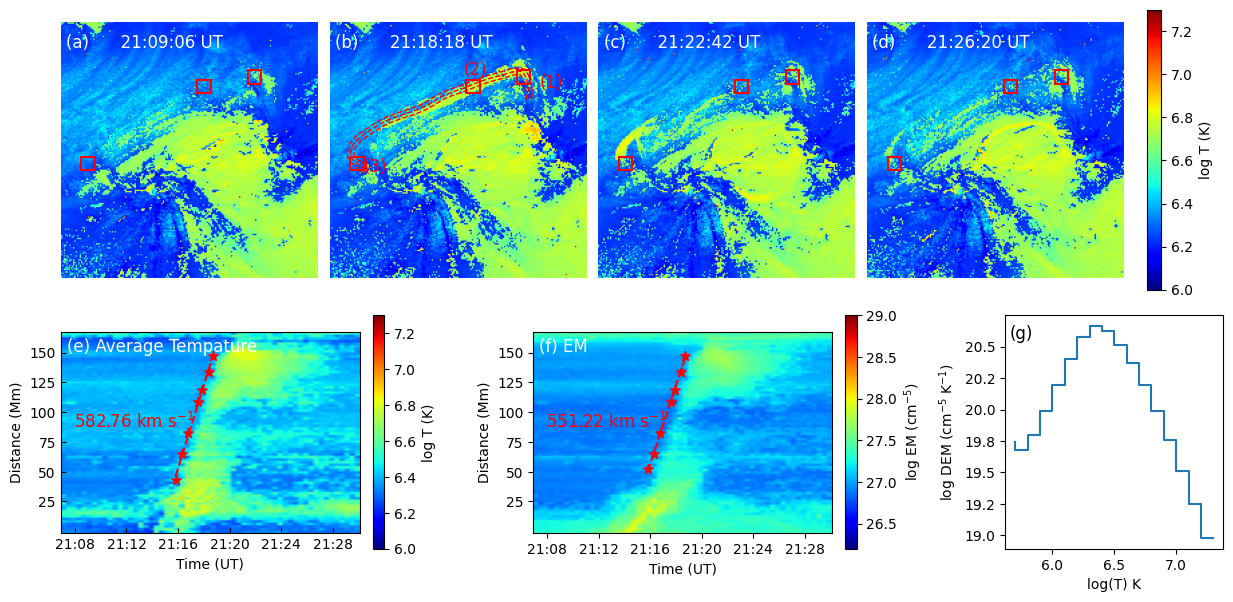

In [10]:
data=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
slice_em=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy')

a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

#算一下距离，这里算的是平均距离，以像素为单位,时间间隔是12s*2=24s
dist1=np.average(np.sqrt(np.diff(a[:,0])**2+np.diff(a[:,1])**2))
dist2=np.average(np.sqrt(np.diff(b[:,0])**2+np.diff(b[:,1])**2))
dist3=np.average(np.sqrt(np.diff(c[:,0])**2+np.diff(c[:,1])**2))
print(dist1,dist2,dist3)
avg_diff=np.average([dist1,dist2,dist3])
print(avg_diff)

rsm=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs=rsm[1].header['DSUN_OBS']
resolution=rsm[1].header['CDELT2']
#k是一角秒对应多少千米
k=sin(np.pi/(3600*180))*dsun_obs/1000
dist=k*resolution*avg_diff
print('离太阳的距离是',dsun_obs,'m')
print('一角秒对应多少千米是',k,'km/arc')
print('分辨率是',resolution,'arc/pixel')
print('尺寸是',dist,'km/pixel')

#接下来算一下纵坐标和横坐标的值
#dist单位是km/pixel avg_dist单位是pixel,除1000变成兆米，乘78是一共多长
print(dist*1e-3*78)
trans_coeff=dist*1e-3
print(trans_coeff)
corr_y=np.zeros(6)
for i in range(len(corr_y)):
    corr_y[i]=25*(i+1)/trans_coeff
    #corr_y[i]=50*(i+1)/trans_coeff
#32是第一个点，对应时间21：07：08
#98是第三十四个点，对应时间21：20：20
#算横轴时间的对应坐标

fig=plt.figure(figsize=(15,7))
gs=gridspec.GridSpec(2,1,height_ratios=[1.2,1],hspace=0.1)

#图1
gs_top=gridspec.GridSpecFromSubplotSpec(1,4,subplot_spec=gs[0],wspace=0.05)
im_list=[]
ax11=fig.add_subplot(gs_top[0])
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
datas=readsav(file_list[10])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax11.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax11.text(0.02,0.9,'(a)      21:09:06 UT',color='white',transform=ax11.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')



#图2
ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
ax22.text(0.02,0.9,'(b)      21:18:18 UT',color='white',transform=ax22.transAxes,fontsize=12)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)

plt.axis('off')


#图3
ax3=fig.add_subplot(gs_top[2])
datas=readsav(file_list[78])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax3.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
ax3.text(0.02,0.9,'(c)      21:22:42 UT',color='white',transform=ax3.transAxes,fontsize=12)
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
plt.gca().add_patch(rect1)
plt.axis('off')

#图4
ax4=fig.add_subplot(gs_top[3])
datas=readsav(file_list[96])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax4.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax4.text(0.02,0.9,'(d)      21:26:20 UT',color='white',transform=ax4.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')
#总的colorbar
cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4], 
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T (K)')
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 -0.015, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

ax_all=[ax11,ax22,ax3,ax4]
for i in range(4):
    left_bottom1=(140,145)
    rect2=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    left_bottom2=(102,138)
    rect1=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    #left_bottom2=(142,140)
    left_bottom3=(15,80)
    rect3=Rectangle(left_bottom3,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    ax=ax_all[i]
    ax.add_patch(rect1)
    ax.add_patch(rect2)
    ax.add_patch(rect3)
    if i==1:
        ax.text(157,142,'(1)',color='red',fontsize=12)
        ax.text(100,152,'(2)',color='red',fontsize=12)
        ax.text(25,79,'(3)',color='red',fontsize=12)

#图5
#gs_bottom=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1],width_ratios=[2,1],wspace=0.2,hspace=0.2)
gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1]
                                            ,width_ratios=[3,3,2],wspace=0.5,hspace=0.2)

corr_x=np.zeros(6)
for i in range(len(corr_x)):
    corr_x[i]=(54+i*240)/24
x_labels=['21:08','21:12','21:16','21:20','21:24','21:28']
#图5
ax5=fig.add_subplot(gs_bottom[0])
im5=ax5.imshow(np.log10(slice),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect=0.5)
pos5 = ax5.get_position()   # 返回 [x0, y0, width, height]
cbar5=fig.colorbar(im5, ax=ax5, orientation='vertical', fraction=0.046, pad=0.04)
cbar5.set_label('log T (K)')
#画散点和曲线
coord=[(5.8+16,20),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x1,y1=zip(*coord)
x1,y1=np.array(x1),np.array(y1)
ax5.scatter(x=x1,y=y1,c='red',marker='*',s=50)
coeff1=np.polyfit(x1,y1,1)
poly1=np.poly1d(coeff1)
#算出来的斜率是6.46pixel_y/pixel_x*网格分辨率2164km/pixel_y
#除横轴分辨率24s/pixel_x，得到582km/s
ax5.text(2,40,r'$\mathrm{582.76\ km \ s^{-1}}$',fontsize=12,color='red')
ax5.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax5.set_ylabel('Distance (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x,labels=x_labels)
ax5.plot(x1,poly1(x1),c='red',linestyle='--')
ax5.tick_params(axis='both',direction='in')
ax5.text(0.02,0.9,'(e) Average Tempature',color='white',transform=ax5.transAxes,fontsize=12)
# ax5.set_position([pos5.x0 + 0.005, pos5.y0, pos5.width, pos5.height])
# cbar_pos = cbar5.ax.get_position()
# cbar5.ax.set_position([cbar_pos.x0 +0.02, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

#图6
ax6=fig.add_subplot(gs_bottom[1])
im6=ax6.imshow(np.log10(slice_em),cmap='jet',origin='lower',vmin=26.2,vmax=29,aspect=0.5)
ax6.text(0.02,0.9,'(f) EM',color='white',transform=ax6.transAxes,fontsize=12)
pos6=ax6.get_position()
cbar6=fig.colorbar(im6, ax=ax6, orientation='vertical', fraction=0.046, pad=0.04)
cbar6.set_label('log EM '+ r'$(\text{cm}^{-5})$')
#画散点和直线
coord2=[(5.8+16,24),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x2,y2=zip(*coord2)
x2,y2=np.array(x2),np.array(y2)
ax6.scatter(x=x2,y=y2,c='red',marker='*',s=50)
coeff2=np.polyfit(x2,y2,1)
poly2=np.poly1d(coeff2)
#算出来的斜率是6.46pixel_y/pixel_x*网格分辨率2164km/pixel_y
v2=coeff2[0]*dist/24
ax6.plot(x2,poly2(x2),c='red',linestyle='--')
ax6.text(2,40,f'{v2:.2f}'+r'$\ \mathrm{km \  s^{-1}}$',fontsize=12,color='red')
#加label
ax6.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax6.set_xticks(ticks=corr_x,labels=x_labels)
ax6.set_xlabel('Time (UT)')
ax6.set_ylabel('Distance (Mm)')
# ax6.set_position([pos6.x0 - 0.005, pos6.y0, pos6.width, pos6.height])
# cbar_pos = cbar6.ax.get_position()
# cbar6.ax.set_position([cbar_pos.x0 -0.005, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

ax7=fig.add_subplot(gs_bottom[2])
data=readsav(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\DEM18-Jun-2024_21_18_18.sav')
result=data['result']
dem_out=result['DEM_OUT'][0]
dem_out_2=dem_out[2:19,138:148,102:112]
avg_dem=np.mean(dem_out_2,axis=(1,2))
x_arr=np.linspace(5.7,7.3,17)
ax7.step(x_arr,np.log10(avg_dem))
ax7.text(0.02,0.9,'(g)',color='black',transform=ax7.transAxes,fontsize=12)
ax7.set_ylabel('log DEM (cm$^{-5}$ K$^{-1}$)')
ax7.set_xlabel('log(T) K')
ax7.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig4\EM_T_DEM_time_distance.pdf',format='pdf', bbox_inches='tight')

5.149874071052627 4.8910559440820895 4.632244169727517
4.891058061620744
离太阳的距离是 151963569604.3406 m
一角秒对应多少千米是 736.7401757413695 km/arc
分辨率是 0.600697994 arc/pixel
尺寸是 2164.5785643123554 km/pixel
168.83712801636375
2.1645785643123556


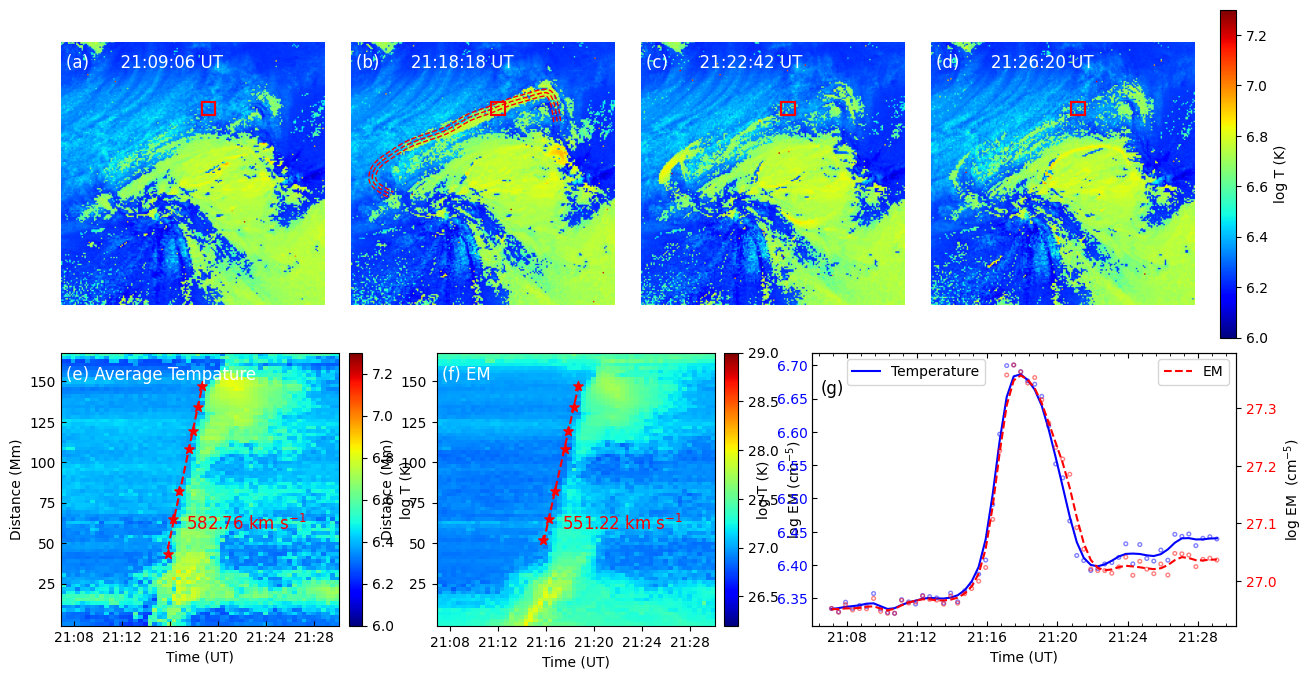

In [21]:
data=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
slice_em=np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy')

a=data['fit_points']
b=data['fit_points2']
c=data['fit_points3']

dist1=np.average(np.sqrt(np.diff(a[:,0])**2+np.diff(a[:,1])**2))
dist2=np.average(np.sqrt(np.diff(b[:,0])**2+np.diff(b[:,1])**2))
dist3=np.average(np.sqrt(np.diff(c[:,0])**2+np.diff(c[:,1])**2))
print(dist1,dist2,dist3)
avg_diff=np.average([dist1,dist2,dist3])
print(avg_diff)

rsm=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs=rsm[1].header['DSUN_OBS']
resolution=rsm[1].header['CDELT2']
k=sin(np.pi/(3600*180))*dsun_obs/1000
dist=k*resolution*avg_diff
print('离太阳的距离是',dsun_obs,'m')
print('一角秒对应多少千米是',k,'km/arc')
print('分辨率是',resolution,'arc/pixel')
print('尺寸是',dist,'km/pixel')

print(dist*1e-3*78)
trans_coeff=dist*1e-3
print(trans_coeff)
corr_y=np.zeros(6)
for i in range(len(corr_y)):
    corr_y[i]=25*(i+1)/trans_coeff


fig=plt.figure(figsize=(16,8))
gs=gridspec.GridSpec(2,1,height_ratios=[1.2,1],hspace=0.05)

gs_top=gridspec.GridSpecFromSubplotSpec(1,4,subplot_spec=gs[0],wspace=0.1)
im_list=[]
ax11=fig.add_subplot(gs_top[0])
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\'+'*.sav')
datas=readsav(file_list[10])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax11.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax11.text(0.02,0.9,'(a)      21:09:06 UT',color='white',transform=ax11.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')

ax22=fig.add_subplot(gs_top[1])
datas=readsav(file_list[56])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax22.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
ax22.text(0.02,0.9,'(b)      21:18:18 UT',color='white',transform=ax22.transAxes,fontsize=12)
ax22.plot(b[:,1]/2,b[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(a[:,1]/2,a[:,0]/2,linestyle='--',color='red',linewidth=1)
ax22.plot(c[:,1]/2,c[:,0]/2,linestyle='--',color='red',linewidth=1)
plt.axis('off')

ax3=fig.add_subplot(gs_top[2])
datas=readsav(file_list[78])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax3.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
ax3.text(0.02,0.9,'(c)      21:22:42 UT',color='white',transform=ax3.transAxes,fontsize=12)
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
plt.gca().add_patch(rect1)
plt.axis('off')

ax4=fig.add_subplot(gs_top[3])
datas=readsav(file_list[96])
result=datas['result']
dem_out=result['DEM_OUT'][0]
smap_temp=result['SMAP_TEMP'][0]
smap_em=result['SMAP_EM'][0]
im=ax4.imshow(np.log10(smap_temp),vmin=6.0,vmax=7.3,cmap='jet',origin='lower')
im_list.append(im)
left_bottom1=(102,138)
rect1=Rectangle(left_bottom1,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
ax4.text(0.02,0.9,'(d)      21:26:20 UT',color='white',transform=ax4.transAxes,fontsize=12)
plt.gca().add_patch(rect1)
plt.axis('off')

cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4], 
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T (K)')
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 -0.015, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

ax_all=[ax11,ax22,ax3,ax4]
for i in range(4):
    left_bottom2=(102,138)
    rect1=Rectangle(left_bottom2,10,10,edgecolor='red',facecolor='none',linewidth=1.5)
    ax=ax_all[i]
    ax.add_patch(rect1)

gs_bottom=gridspec.GridSpecFromSubplotSpec(1,3,subplot_spec=gs[1]
                                            ,width_ratios=[2,2,3],wspace=0.4,hspace=0.2)

corr_x=np.zeros(6)
for i in range(len(corr_x)):
    corr_x[i]=(54+i*240)/24
x_labels=['21:08','21:12','21:16','21:20','21:24','21:28']

ax5=fig.add_subplot(gs_bottom[0])
im5=ax5.imshow(np.log10(slice),cmap='jet',origin='lower',vmin=6.0,vmax=7.3,aspect='auto')
pos5 = ax5.get_position()
cbar5=fig.colorbar(im5, ax=ax5, orientation='vertical', fraction=0.046, pad=0.04)
cbar5.set_label('log T (K)')
coord=[(5.8+16,20),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x1,y1=zip(*coord)
x1,y1=np.array(x1),np.array(y1)
ax5.scatter(x=x1,y=y1,c='red',marker='*',s=50)
coeff1=np.polyfit(x1,y1,1)
poly1=np.poly1d(coeff1)
ax5.text(0.45,0.35,r'$\mathrm{582.76\ km \ s^{-1}}$',fontsize=12,color='red',transform=ax5.transAxes)
ax5.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax5.set_ylabel('Distance (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x,labels=x_labels)
ax5.plot(x1,poly1(x1),c='red',linestyle='--')
ax5.tick_params(axis='both',direction='in')
ax5.text(0.02,0.9,'(e) Average Tempature',color='white',transform=ax5.transAxes,fontsize=12)

ax6=fig.add_subplot(gs_bottom[1])
im6=ax6.imshow(np.log10(slice_em),cmap='jet',origin='lower',vmin=26.2,vmax=29,aspect='auto')
ax6.text(0.02,0.9,'(f) EM',color='white',transform=ax6.transAxes,fontsize=12)
pos6=ax6.get_position()
cbar6=fig.colorbar(im6, ax=ax6, orientation='vertical', fraction=0.046, pad=0.04)
cbar6.set_label('log EM '+ r'$(\text{cm}^{-5})$')
coord2=[(5.8+16,24),(7+16,30),(8.2+16,38),(10.2+16,50),(11+16,55),(12.2+16,62),(13+16,68)]
x2,y2=zip(*coord2)
x2,y2=np.array(x2),np.array(y2)
ax6.scatter(x=x2,y=y2,c='red',marker='*',s=50)
coeff2=np.polyfit(x2,y2,1)
poly2=np.poly1d(coeff2)
v2=coeff2[0]*dist/24
ax6.plot(x2,poly2(x2),c='red',linestyle='--')
ax6.text(0.45,0.35,f'{v2:.2f}'+r'$\ \mathrm{km \  s^{-1}}$',fontsize=12,color='red',transform=ax6.transAxes)
ax6.set_yticks(ticks=corr_y,labels=['25','50','75','100','125','150'])
ax6.set_xticks(ticks=corr_x,labels=x_labels)
ax6.set_xlabel('Time (UT)')
ax6.set_ylabel('Distance (Mm)')

avg_temp_r2 = np.zeros(58)
avg_em_r2 = np.zeros(58)
for i in range(58):
    datas = readsav(file_list[i*2])
    result = datas['result']
    smap_temp = result['SMAP_TEMP'][0]
    smap_em = result['SMAP_EM'][0]
    avg_temp_r2[i] = np.mean(smap_temp[138:148, 102:112])
    avg_em_r2[i] = np.mean(smap_em[138:148, 102:112])
logT_r2 = np.log10(avg_temp_r2)
logem_r2 = np.log10(avg_em_r2)

ax7 = fig.add_subplot(gs_bottom[2])
sigma = 1.2
alpha = 0.5
data_r2 = logT_r2[:56]
smoothed_r2 = gaussian_filter1d(data_r2, sigma=sigma)
ax7.plot(np.linspace(0,55,56), smoothed_r2, label='Temperature', color='blue')
ax7.scatter(np.linspace(0,55,56), logT_r2[:56], alpha=alpha, s=7, facecolor='none', edgecolor='blue')
ax7.tick_params(axis='y', labelcolor='blue')
ax7.set_ylabel('log T (K)')
ax7.set_xlabel('Time (UT)')
ax7.set_xticks(ticks=corr_x, labels=x_labels)
ax7.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax7.yaxis.set_minor_locator(ticker.NullLocator())
ax7.text(0.02, 0.85, '(g)', color='black', transform=ax7.transAxes, fontsize=12)
ax7.legend(loc='upper left', bbox_to_anchor=(0.065, 1))

ax77 = ax7.twinx()
data_em_r2 = logem_r2[:56]
smoothed_em_r2 = gaussian_filter1d(data_em_r2, sigma=sigma)
ax77.plot(np.linspace(0,55,56), smoothed_em_r2, label='EM', linestyle='--', color='red')
ax77.scatter(np.linspace(0,55,56), logem_r2[:56], alpha=alpha, s=7, facecolor='none', edgecolor='red')
ax77.set_ylabel('log EM  ' + r'$(\text{cm}^{-5})$')
ax77.tick_params(axis='y', labelcolor='red')
ax77.legend(loc='upper right')

ax7.tick_params(axis='x', which='both', direction='in', top=True)
ax7.tick_params(axis='y', which='both', direction='in')

# ---------- 下排主图框与上排图像框对齐 ----------
fig.canvas.draw()

# 让(e)图的图像区域左边界对齐(a)图
left = ax11.get_position().x0

# 下排整体右边可以用到上排总 colorbar 左侧附近，让三幅图更宽敞
right = cbar.ax.get_position().x1

y0 = ax5.get_position().y0
h = ax5.get_position().height

# 可调参数
gap = 0.045      # 三个面板之间的空隙
pad = 0.006      # 图和colorbar之间的距离
cbw = 0.010      # e/f两个colorbar宽度

# 三个主图宽度比例，可以稍微让(g)宽一点
ratio5, ratio6, ratio7 = 2.1, 2.1, 3.2

W = right - left
unit = (W - 2 * gap - 2 * (pad + cbw)) / (ratio5 + ratio6 + ratio7)

w5 = ratio5 * unit
w6 = ratio6 * unit
w7 = ratio7 * unit

x5 = left
x6 = x5 + w5 + pad + cbw + gap
x7 = x6 + w6 + pad + cbw + gap

ax5.set_position([x5, y0, w5, h])
cbar5.ax.set_position([x5 + w5 + pad, y0, cbw, h])

ax6.set_position([x6, y0, w6, h])
cbar6.ax.set_position([x6 + w6 + pad, y0, cbw, h])

ax7.set_position([x7, y0, w7, h])
ax77.set_position(ax7.get_position())
#plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\EM_T_DEM_time_distance.pdf',format='pdf', bbox_inches='tight')

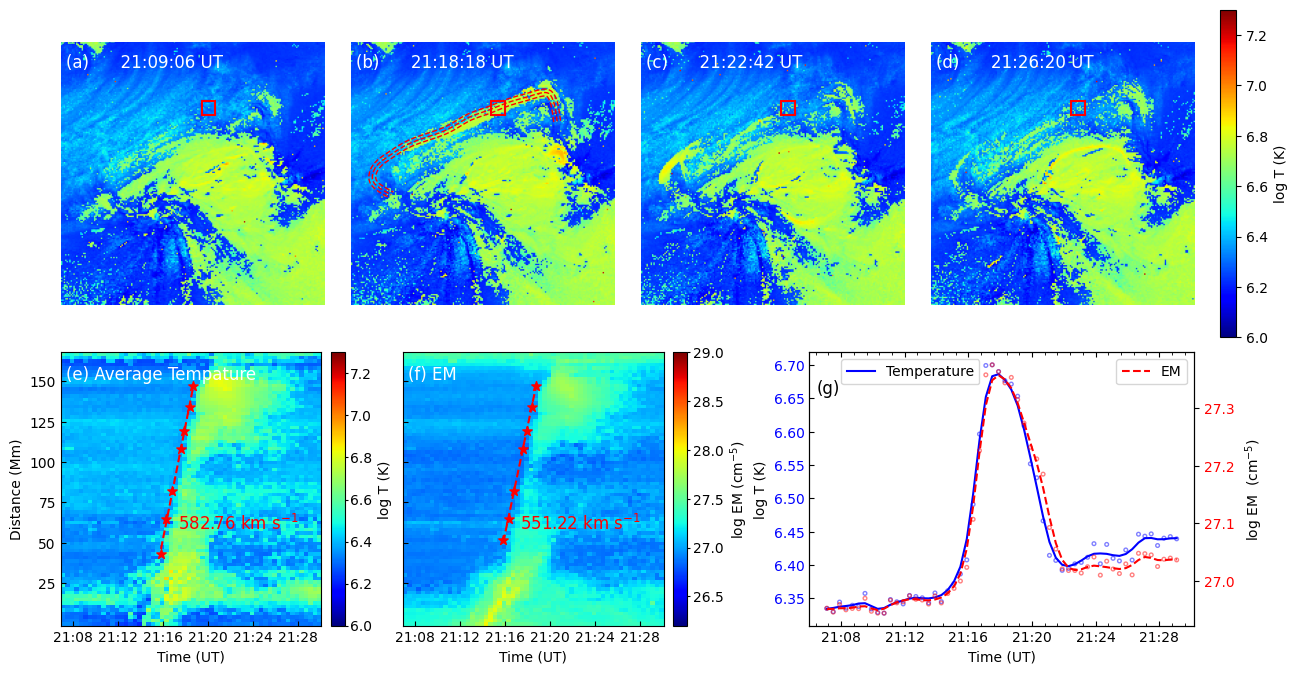

In [25]:
data = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\fit_points.npz')
slice = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix.npy')
slice_em = np.load(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\result_matrix_em.npy')

a = data['fit_points']
b = data['fit_points2']
c = data['fit_points3']

dist1 = np.average(np.sqrt(np.diff(a[:, 0])**2 + np.diff(a[:, 1])**2))
dist2 = np.average(np.sqrt(np.diff(b[:, 0])**2 + np.diff(b[:, 1])**2))
dist3 = np.average(np.sqrt(np.diff(c[:, 0])**2 + np.diff(c[:, 1])**2))
avg_diff = np.average([dist1, dist2, dist3])

rsm = fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T210044Z.131.image_lev1.fits')
dsun_obs = rsm[1].header['DSUN_OBS']
resolution = rsm[1].header['CDELT2']
k = sin(np.pi / (3600 * 180)) * dsun_obs / 1000
dist = k * resolution * avg_diff

trans_coeff = dist * 1e-3
corr_y = np.zeros(6)
for i in range(len(corr_y)):
    corr_y[i] = 25 * (i + 1) / trans_coeff

fig = plt.figure(figsize=(16, 8))
gs = gridspec.GridSpec(2, 1, height_ratios=[1.2, 1], hspace=0.05)

gs_top = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=gs[0], wspace=0.1)
im_list = []

file_list = glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\DEM2\\' + '*.sav')

ax11 = fig.add_subplot(gs_top[0])
datas = readsav(file_list[10])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax11.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax11.text(0.02, 0.9, '(a)      21:09:06 UT', color='white', transform=ax11.transAxes, fontsize=12)
ax11.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax11.axis('off')

ax22 = fig.add_subplot(gs_top[1])
datas = readsav(file_list[56])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax22.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax22.text(0.02, 0.9, '(b)      21:18:18 UT', color='white', transform=ax22.transAxes, fontsize=12)
ax22.plot(b[:, 1] / 2, b[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.plot(a[:, 1] / 2, a[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.plot(c[:, 1] / 2, c[:, 0] / 2, linestyle='--', color='red', linewidth=1)
ax22.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax22.axis('off')

ax3 = fig.add_subplot(gs_top[2])
datas = readsav(file_list[78])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax3.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax3.text(0.02, 0.9, '(c)      21:22:42 UT', color='white', transform=ax3.transAxes, fontsize=12)
ax3.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax3.axis('off')

ax4 = fig.add_subplot(gs_top[3])
datas = readsav(file_list[96])
result = datas['result']
smap_temp = result['SMAP_TEMP'][0]
im = ax4.imshow(np.log10(smap_temp), vmin=6.0, vmax=7.3, cmap='jet', origin='lower')
im_list.append(im)
ax4.text(0.02, 0.9, '(d)      21:26:20 UT', color='white', transform=ax4.transAxes, fontsize=12)
ax4.add_patch(Rectangle((102, 138), 10, 10, edgecolor='red', facecolor='none', linewidth=1.5))
ax4.axis('off')

cbar = fig.colorbar(im_list[0], ax=[ax11, ax22, ax3, ax4],
                    orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('log T (K)')
cbar_pos = cbar.ax.get_position()
cbar.ax.set_position([cbar_pos.x0 - 0.015, cbar_pos.y0, cbar_pos.width, cbar_pos.height])

gs_bottom = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[1],
    width_ratios=[2, 2, 3],
    wspace=0.4,
    hspace=0.2
)

corr_x = np.zeros(6)
for i in range(len(corr_x)):
    corr_x[i] = (54 + i * 240) / 24
x_labels = ['21:08', '21:12', '21:16', '21:20', '21:24', '21:28']

ax5 = fig.add_subplot(gs_bottom[0])
im5 = ax5.imshow(np.log10(slice), cmap='jet', origin='lower',
                 vmin=6.0, vmax=7.3, aspect='auto')
cbar5 = fig.colorbar(im5, ax=ax5, orientation='vertical', fraction=0.046, pad=0.04)
cbar5.set_label('log T (K)')

coord = [(5.8 + 16, 20), (7 + 16, 30), (8.2 + 16, 38),
         (10.2 + 16, 50), (11 + 16, 55), (12.2 + 16, 62), (13 + 16, 68)]
x1, y1 = zip(*coord)
x1, y1 = np.array(x1), np.array(y1)
coeff1 = np.polyfit(x1, y1, 1)
poly1 = np.poly1d(coeff1)

ax5.scatter(x=x1, y=y1, c='red', marker='*', s=50)
ax5.plot(x1, poly1(x1), c='red', linestyle='--')
ax5.text(0.45, 0.35, r'$\mathrm{582.76\ km \ s^{-1}}$',
         fontsize=12, color='red', transform=ax5.transAxes)
ax5.set_yticks(ticks=corr_y, labels=['25', '50', '75', '100', '125', '150'])
ax5.set_ylabel('Distance (Mm)')
ax5.set_xlabel('Time (UT)')
ax5.set_xticks(ticks=corr_x, labels=x_labels)
ax5.tick_params(axis='both', direction='in')
ax5.text(0.02, 0.9, '(e) Average Tempature',
         color='white', transform=ax5.transAxes, fontsize=12)

ax6 = fig.add_subplot(gs_bottom[1])
im6 = ax6.imshow(np.log10(slice_em), cmap='jet', origin='lower',
                 vmin=26.2, vmax=29, aspect='auto')
cbar6 = fig.colorbar(im6, ax=ax6, orientation='vertical', fraction=0.046, pad=0.04)
cbar6.set_label('log EM ' + r'$(\text{cm}^{-5})$')

coord2 = [(5.8 + 16, 24), (7 + 16, 30), (8.2 + 16, 38),
          (10.2 + 16, 50), (11 + 16, 55), (12.2 + 16, 62), (13 + 16, 68)]
x2, y2 = zip(*coord2)
x2, y2 = np.array(x2), np.array(y2)
coeff2 = np.polyfit(x2, y2, 1)
poly2 = np.poly1d(coeff2)
v2 = coeff2[0] * dist / 24

ax6.scatter(x=x2, y=y2, c='red', marker='*', s=50)
ax6.plot(x2, poly2(x2), c='red', linestyle='--')
ax6.text(0.45, 0.35, f'{v2:.2f}' + r'$\ \mathrm{km \  s^{-1}}$',
         fontsize=12, color='red', transform=ax6.transAxes)
ax6.set_yticks(ticks=corr_y, labels=['25', '50', '75', '100', '125', '150'])
ax6.set_xticks(ticks=corr_x, labels=x_labels)
ax6.set_xlabel('Time (UT)')
ax6.set_ylabel('')
ax6.set_yticklabels([])
ax6.tick_params(axis='both', direction='in')
ax6.text(0.02, 0.9, '(f) EM',
         color='white', transform=ax6.transAxes, fontsize=12)

avg_temp_r2 = np.zeros(58)
avg_em_r2 = np.zeros(58)
for i in range(58):
    datas = readsav(file_list[i * 2])
    result = datas['result']
    smap_temp = result['SMAP_TEMP'][0]
    smap_em = result['SMAP_EM'][0]
    avg_temp_r2[i] = np.mean(smap_temp[138:148, 102:112])
    avg_em_r2[i] = np.mean(smap_em[138:148, 102:112])

logT_r2 = np.log10(avg_temp_r2)
logem_r2 = np.log10(avg_em_r2)

ax7 = fig.add_subplot(gs_bottom[2])
sigma = 1.2
alpha = 0.5

data_r2 = logT_r2[:56]
smoothed_r2 = gaussian_filter1d(data_r2, sigma=sigma)
ax7.plot(np.linspace(0, 55, 56), smoothed_r2, label='Temperature', color='blue')
ax7.scatter(np.linspace(0, 55, 56), logT_r2[:56],
            alpha=alpha, s=7, facecolor='none', edgecolor='blue')
ax7.tick_params(axis='y', labelcolor='blue')
ax7.set_ylabel('log T (K)')
ax7.set_xlabel('Time (UT)')
ax7.set_xticks(ticks=corr_x, labels=x_labels)
ax7.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax7.yaxis.set_minor_locator(ticker.NullLocator())
ax7.text(0.02, 0.85, '(g)', color='black', transform=ax7.transAxes, fontsize=12)
ax7.legend(loc='upper left', bbox_to_anchor=(0.065, 1))

ax77 = ax7.twinx()
data_em_r2 = logem_r2[:56]
smoothed_em_r2 = gaussian_filter1d(data_em_r2, sigma=sigma)
ax77.plot(np.linspace(0, 55, 56), smoothed_em_r2,
          label='EM', linestyle='--', color='red')
ax77.scatter(np.linspace(0, 55, 56), logem_r2[:56],
             alpha=alpha, s=7, facecolor='none', edgecolor='red')
ax77.set_ylabel('log EM  ' + r'$(\text{cm}^{-5})$')
ax77.tick_params(axis='y', labelcolor='red')
ax77.legend(loc='upper right')

ax7.tick_params(axis='x', which='both', direction='in', top=True)
ax7.tick_params(axis='y', which='both', direction='in')

# ---------- 手动调整下排布局，避免 ticks 混在一起 ----------
fig.canvas.draw()

left = ax11.get_position().x0
right = ax4.get_position().x1

y0 = ax5.get_position().y0
h = ax5.get_position().height

gap_ef = 0.035
gap_fg = 0.075
pad = 0.006
cbw = 0.010

ratio5, ratio6, ratio7 = 2.1, 2.1, 3.1

W = right - left
unit = (W - gap_ef - gap_fg - 2 * (pad + cbw)) / (ratio5 + ratio6 + ratio7)

w5 = ratio5 * unit
w6 = ratio6 * unit
w7 = ratio7 * unit

x5 = left
x6 = x5 + w5 + pad + cbw + gap_ef
x7 = x6 + w6 + pad + cbw + gap_fg

ax5.set_position([x5, y0, w5, h])
cbar5.ax.set_position([x5 + w5 + pad, y0, cbw, h])

ax6.set_position([x6, y0, w6, h])
cbar6.ax.set_position([x6 + w6 + pad, y0, cbw, h])

ax7.set_position([x7, y0, w7, h])
ax77.set_position(ax7.get_position())

for cb in [cbar5, cbar6]:
    cb.ax.tick_params(labelsize=10, length=2, pad=2)
    cb.ax.yaxis.labelpad = 4

ax7.yaxis.labelpad = 4
ax77.yaxis.labelpad = 6

plt.savefig(
    r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\EM_T_DEM_time_distance.pdf',
    format='pdf',
    bbox_inches='tight'
)

<font color=cyan>画双云模型</font>

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00


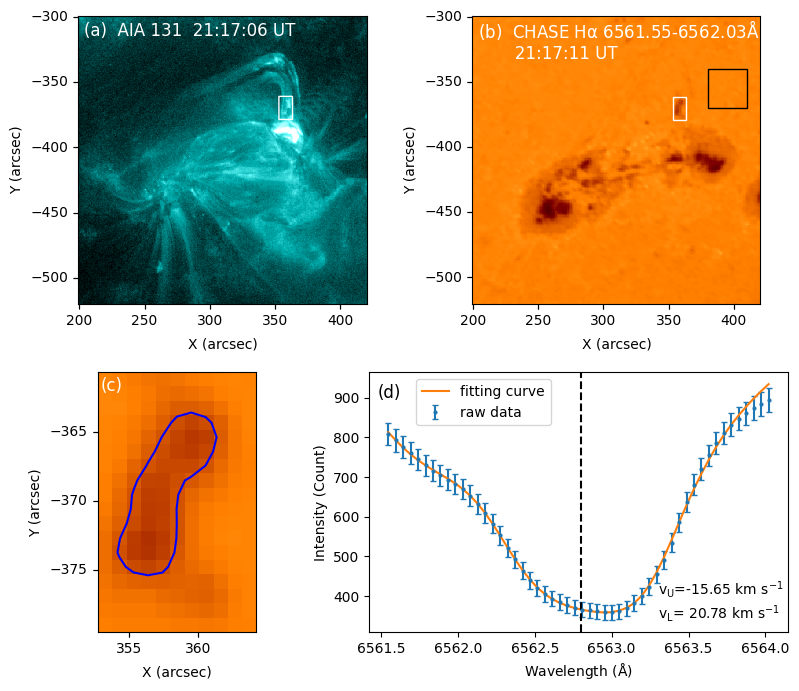

In [32]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I

import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
#数据准备
dir=r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
left_index=44
right_index=96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam=lam00[left_index:right_index]#±1.5A
I0=rsm[1].data[left_index:right_index,797:826,1540:1569].mean(axis=(1,2))
print(lam00[39],lam00[44],lam00[54],lam00[96],lam00[101])
lam0 = 6562.8
c_km = 299792.458  # 光速 (km/s)
# 1. wavelength → velocity
lam=lam00[left_index:right_index]#±1.5A
vel = (lam - lam0) / lam0 * c_km  # km/s

#画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)

#aia131图像
dir2=r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia=sunpy.map.Map(dir2)
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=aia.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=aia.coordinate_frame)
sub_aia=aia.submap(left_bottom,top_right=top_right)
#----------------------------------------------------------------------------------------------------------------------------
#图1
fig=plt.figure(figsize=(9.5,8))
gs=gridspec.GridSpec(2,1,hspace=0.25,height_ratios=[1,0.9])
gs_top=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[0],wspace=0.15,width_ratios=[1,1])
old_norm=sub_aia.plot_settings['norm']
old_norm.vmin=0.01
old_norm.vmax=2000
ax1=fig.add_subplot(gs_top[0],projection=sub_aia)
sub_aia.plot(axes=ax1,norm=old_norm)
#------------------------------------------------------------------------------------------------------------------
#图2
ax2=fig.add_subplot(gs_top[1],projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2,cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean())

#point1是宁静区左下角
point1=SkyCoord(Tx=380*u.arcsec,Ty=-370*u.arcsec,frame=hawing_map.coordinate_frame)
xpix1,ypix1=hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')
#point2是宁静区右上角
point2=SkyCoord(Tx=410*u.arcsec,Ty=-340*u.arcsec,frame=hawing_map.coordinate_frame)
xpix2,ypix2=hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')
sub_hawing_map.draw_quadrangle(point1,top_right=point2,axes=ax2,edgecolor='black')

jet_point=(1520,791)
point3=hawing_map.wcs.pixel_to_world(jet_point[0],jet_point[1])
#ax2.plot_coord(point3,marker='o',markersize=3)
xpix3,ypix3=hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')
#point4是喷流选取左下角
jet_point4=(1515,789)
point4=hawing_map.wcs.pixel_to_world(jet_point4[0],jet_point4[1])
xpix4,ypix4=hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')
#point5是喷流选取右上角
jet_point5=(1525,806)
point5=hawing_map.wcs.pixel_to_world(jet_point5[0],jet_point5[1])
#point5=SkyCoord(Tx=364*u.arcsec,Ty=-363*u.arcsec,frame=hawing_map.coordinate_frame)
xpix5,ypix5=hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4,top_right=point5,axes=ax2,edgecolor='white')
sub_aia.draw_quadrangle(point4,top_right=point5,axes=ax1,edgecolor='white')
#----------------------------------------------------------------------------------------------
#图3
gs_down=gridspec.GridSpecFromSubplotSpec(1,2,subplot_spec=gs[1],width_ratios=[0.6,1])
jet_region=sub_hawing_map.submap(point4,top_right=point5)
ax3=fig.add_subplot(gs_down[0],projection=jet_region)
im=jet_region.plot(axes=ax3,cmap='afmhot',vmin=0, vmax = 2 * sub_hawing_map.data.mean())
ax3.coords[0].set_ticks(number=4)

contour=ax3.contour(jet_region.data,levels=[800],colors=['blue'],transform=ax3.get_transform(jet_region.wcs))

#-------------------------------------------------------------------------------------------------
#图4
ax4=fig.add_subplot(gs_down[1])
#获取待拟合光谱
#由contour生成mask
cs = contour
from matplotlib.path import Path
# 初始化 mask
mask = np.zeros_like(jet_region.data, dtype=bool)
# 构造像素坐标网格
ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T  # (N, 2)
# 遍历所有封闭区域
for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)
data_jet=rsm[1].data[left_index:right_index,789:807,1515:1526]
data_mask=np.tile(~mask,(right_index-left_index,1,1))
jet_masked=np.ma.array(data_jet,mask=data_mask)
I=jet_masked.mean(axis=(1,2))

#获取拟合参数
x_opt=np.load('x_opt.npy')
ax4.errorbar(lam,I,yerr=np.sqrt(I),fmt='o',capsize=2,markersize=2,label='raw data')
y_fit = double_cloud_vel(x_opt, vel, I0)
ax4.plot(lam, y_fit, label='fitting curve')
ax4.axvline(x=6562.8,linestyle='--',color='black')
ax4.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
ax4.set_ylabel('Intensity (Count)')
ax4.legend(bbox_to_anchor=(0.45, 0.77))

#---------------------------------------------------------------------------------------------------
#画图乱七八糟的部分
ax_all=[ax1,ax2,ax3]
for ax in ax_all:
    #ax.set_xlabel('X (arcsecs)')
    ax.set_xlabel('X (arcsec)',labelpad=1.2)
    ax.set_ylabel('Y (arcsec)')
    ax.tick_params(axis='x',which='both',bottom=True,labelbottom=True,top=False,labeltop=False)
    ax.tick_params(axis='y',which='both',left=True,labelleft=True,right=False,labelright=False) 
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.coords[0].set_major_formatter('s',show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s',show_decimal_unit=False)
    ax.set_title('')
ax_all[0].text(0.02,0.93,'(a)  AIA 131  21:17:06 UT',color='white',transform=ax_all[0].transAxes,fontsize=12)
ax_all[1].text(0.02,0.85,r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$'+'\n       21:17:11 UT',color='white',transform=ax_all[1].transAxes,fontsize=12)
ax_all[2].text(0.02,0.93,'(c)',color='white',transform=ax_all[2].transAxes,fontsize=12)
ax4.text(0.02,0.9,'(d)',color='black',transform=ax4.transAxes,fontsize=12)
ax4.text(0.69,0.05,r'$\mathrm{v_U}$'+'=-15.65 '+r'$\mathrm{km \ s^{-1}}$'+'\n'+r'$\mathrm{v_L} $'+'= 20.78 '+r'$\mathrm{km \ s^{-1}}$',color='black',
         fontsize=10,transform=ax4.transAxes)
plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\double_cloud.pdf',format='pdf',bbox_inches='tight', pad_inches=0.1)

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00


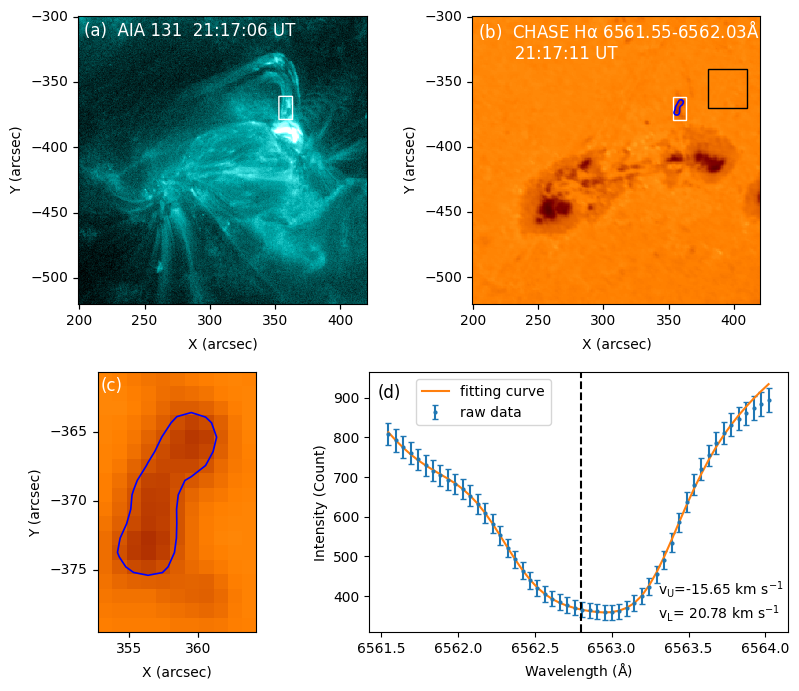

In [ ]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I


import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

# 数据准备
dir = r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm = fits.open(dir)

left_index = 44
right_index = 96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam00[left_index:right_index]  # ±1.5A
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))

print(lam00[39], lam00[44], lam00[54], lam00[96], lam00[101])

lam0 = 6562.8
c_km = 299792.458
vel = (lam - lam0) / lam0 * c_km  # km/s

# 画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime='2024-06-18 21:17:11', observer='earth', frame=frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                            reference_pixel=[rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel, 
                                            scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(left_bottom, top_right=top_right)

# aia131 图像
dir2 = r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia = sunpy.map.Map(dir2)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=aia.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=aia.coordinate_frame)
sub_aia = aia.submap(left_bottom, top_right=top_right)

# ----------------------------------------------------------------------------------------------------------------------------
# 图1
fig = plt.figure(figsize=(9.5, 8))
gs = gridspec.GridSpec(2, 1, hspace=0.25, height_ratios=[1, 0.9])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.15, width_ratios=[1, 1])

old_norm = sub_aia.plot_settings['norm']
old_norm.vmin = 0.01
old_norm.vmax = 2000

ax1 = fig.add_subplot(gs_top[0], projection=sub_aia)
sub_aia.plot(axes=ax1, norm=old_norm)

# ------------------------------------------------------------------------------------------------------------------
# 图2
ax2 = fig.add_subplot(gs_top[1], projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2, cmap='afmhot', vmin=0, vmax=2 * sub_hawing_map.data.mean())

# point1 是宁静区左下角
point1 = SkyCoord(Tx=380 * u.arcsec, Ty=-370 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix1, ypix1 = hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')

# point2 是宁静区右上角
point2 = SkyCoord(Tx=410 * u.arcsec, Ty=-340 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix2, ypix2 = hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')

sub_hawing_map.draw_quadrangle(point1, top_right=point2, axes=ax2, edgecolor='black')

jet_point = (1520, 791)
point3 = hawing_map.wcs.pixel_to_world(jet_point[0], jet_point[1])
xpix3, ypix3 = hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')

# point4 是喷流选取左下角
jet_point4 = (1515, 789)
point4 = hawing_map.wcs.pixel_to_world(jet_point4[0], jet_point4[1])
xpix4, ypix4 = hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')

# point5 是喷流选取右上角
jet_point5 = (1525, 806)
point5 = hawing_map.wcs.pixel_to_world(jet_point5[0], jet_point5[1])
xpix5, ypix5 = hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4, top_right=point5, axes=ax2, edgecolor='white')
sub_aia.draw_quadrangle(point4, top_right=point5, axes=ax1, edgecolor='white')

# 先生成 jet_region，这样 b 图和 c 图可以共用同一个 contour
jet_region = sub_hawing_map.submap(point4, top_right=point5)

# 把 c 图中的 contour 同样画到 b 图中
contour_b = ax2.contour(jet_region.data, levels=[800], colors=['blue'], linewidths=1.2, transform=ax2.get_transform(jet_region.wcs))

# ----------------------------------------------------------------------------------------------
# 图3
gs_down = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], width_ratios=[0.6, 1])

ax3 = fig.add_subplot(gs_down[0], projection=jet_region)
im = jet_region.plot(axes=ax3, cmap='afmhot', vmin=0, vmax=2 * sub_hawing_map.data.mean())
ax3.coords[0].set_ticks(number=4)

contour = ax3.contour(jet_region.data, levels=[800], colors=['blue'], linewidths=1.2, transform=ax3.get_transform(jet_region.wcs))

# -------------------------------------------------------------------------------------------------
# 图4
ax4 = fig.add_subplot(gs_down[1])

# 获取待拟合光谱
# 由 contour 生成 mask
cs = contour

from matplotlib.path import Path

mask = np.zeros_like(jet_region.data, dtype=bool)

ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T

for path in cs.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)

data_jet = rsm[1].data[left_index:right_index, 789:807, 1515:1526]
data_mask = np.tile(~mask, (right_index - left_index, 1, 1))
jet_masked = np.ma.array(data_jet, mask=data_mask)
I = jet_masked.mean(axis=(1, 2))

# 获取拟合参数
x_opt = np.load('x_opt.npy')

ax4.errorbar(lam, I, yerr=np.sqrt(I), fmt='o', capsize=2, markersize=2, label='raw data')
y_fit = double_cloud_vel(x_opt, vel, I0)
ax4.plot(lam, y_fit, label='fitting curve')
ax4.axvline(x=6562.8, linestyle='--', color='black')
ax4.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
ax4.set_ylabel('Intensity (Count)')
ax4.legend(bbox_to_anchor=(0.45, 0.77))

# ---------------------------------------------------------------------------------------------------
# 画图乱七八糟的部分
ax_all = [ax1, ax2, ax3]

for ax in ax_all:
    ax.set_xlabel('X (arcsec)', labelpad=1.2)
    ax.set_ylabel('Y (arcsec)')
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True, top=False, labeltop=False)
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, right=False, labelright=False)
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.coords[0].set_major_formatter('s', show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s', show_decimal_unit=False)
    ax.set_title('')

ax_all[0].text(0.02, 0.93, '(a)  AIA 131  21:17:06 UT', color='white', transform=ax_all[0].transAxes, fontsize=12)
ax_all[1].text(0.02, 0.85, r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$' + '\n       21:17:11 UT',
                color='white', transform=ax_all[1].transAxes, fontsize=12)
ax_all[2].text(0.02, 0.93, '(c)', color='white', transform=ax_all[2].transAxes, fontsize=12)

ax4.text(0.02, 0.9, '(d)', color='black', transform=ax4.transAxes, fontsize=12)
ax4.text(0.69, 0.05, r'$\mathrm{v_U}$' + '=-15.65 ' + r'$\mathrm{km \ s^{-1}}$' + '\n'
          + r'$\mathrm{v_L} $' + '= 20.78 ' + r'$\mathrm{km \ s^{-1}}$', color='black', fontsize=10, transform=ax4.transAxes)

plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\double_cloud.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)

6561.305598407436 6561.5480186241975 6562.032859057719 6564.069188878513 6564.3116090952735
宁静区左下角的位置  y:797.58,x:1540.66
宁静区右上角的位置  y:826.32,x:1569.41
喷流点选取的位置  y:791.00,x:1520.00
喷流选取的位置  y:789.00,x:1515.00
喷流选取的位置  y:806.00,x:1525.00


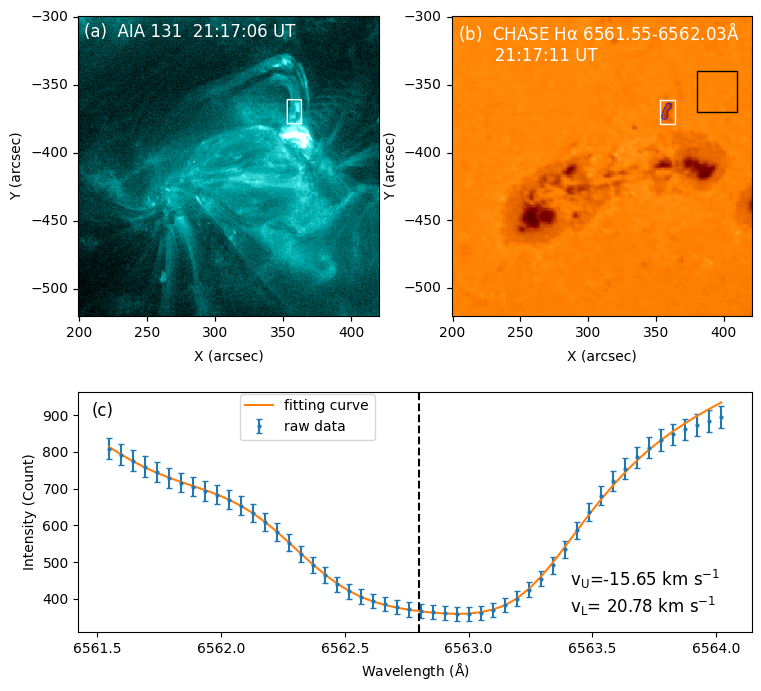

In [27]:
def double_cloud_vel(params, vel, Icont):
    ltauL, ltauU, vL, vU, lWl, lWu, SL, SU = params
    tau0L = np.exp(ltauL)
    tau0U = np.exp(ltauU)
    WL = np.exp(lWl)
    WU = np.exp(lWu)
    
    tauL = tau0L * np.exp(-((vel - vL)**2) / (WL**2))
    tauU = tau0U * np.exp(-((vel - vU)**2) / (WU**2))
    
    I = Icont * np.exp(-(tauL + tauU)) \
        + SL * (1 - np.exp(-tauL)) * np.exp(-tauU) \
        + SU * (1 - np.exp(-tauU))
    return I


import matplotlib as mpl
mpl.rcParams['text.usetex'] = False

# 数据准备
dir = r'C:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm = fits.open(dir)

left_index = 44
right_index = 96
lam00 = rsm[1].header['CRVAL3'] + np.arange(rsm[1].header['NAXIS3']) * rsm[1].header['CDELT3']
lam = lam00[left_index:right_index]  # ±1.5A
I0 = rsm[1].data[left_index:right_index, 797:826, 1540:1569].mean(axis=(1, 2))

print(lam00[39], lam00[44], lam00[54], lam00[96], lam00[101])

lam0 = 6562.8
c_km = 299792.458
vel = (lam - lam0) / lam0 * c_km  # km/s

# 画图
hawing = rsm[1].data[44:54, :, :].mean(axis=0)
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime='2024-06-18 21:17:11', observer='earth', frame=frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS, reference_pixel=[rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel, scale=[0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel, telescope='CHASE', instrument='RSM')
hawing_map = sunpy.map.Map(hawing, headerwing)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=hawing_map.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=hawing_map.coordinate_frame)
sub_hawing_map = hawing_map.submap(left_bottom, top_right=top_right)

# aia131 图像
dir2 = r'C:\Learning\PHD1st\magnetic_reconnecion\data\AIA2\131\aia.lev1_euv_12s.2024-06-18T211708Z.131.image_lev1.fits'
aia = sunpy.map.Map(dir2)

left_bottom = SkyCoord(Tx=200 * u.arcsec, Ty=-520 * u.arcsec, frame=aia.coordinate_frame)
top_right = SkyCoord(Tx=420 * u.arcsec, Ty=-300 * u.arcsec, frame=aia.coordinate_frame)
sub_aia = aia.submap(left_bottom, top_right=top_right)

# ----------------------------------------------------------------------------------------------------------------------------
# 图1
fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(2, 1, hspace=0.28, height_ratios=[1, 0.8])
gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0], wspace=0.15, width_ratios=[1, 1])

old_norm = sub_aia.plot_settings['norm']
old_norm.vmin = 0.01
old_norm.vmax = 2000

ax1 = fig.add_subplot(gs_top[0], projection=sub_aia)
sub_aia.plot(axes=ax1, norm=old_norm)

# ------------------------------------------------------------------------------------------------------------------
# 图2
ax2 = fig.add_subplot(gs_top[1], projection=sub_hawing_map)
sub_hawing_map.plot(axes=ax2, cmap='afmhot', vmin=0, vmax=2 * sub_hawing_map.data.mean())

# point1 是宁静区左下角
point1 = SkyCoord(Tx=380 * u.arcsec, Ty=-370 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix1, ypix1 = hawing_map.world_to_pixel(point1)
print(f'宁静区左下角的位置  y:{ypix1.value:.2f},x:{xpix1.value:.2f}')

# point2 是宁静区右上角
point2 = SkyCoord(Tx=410 * u.arcsec, Ty=-340 * u.arcsec, frame=hawing_map.coordinate_frame)
xpix2, ypix2 = hawing_map.world_to_pixel(point2)
print(f'宁静区右上角的位置  y:{ypix2.value:.2f},x:{xpix2.value:.2f}')

sub_hawing_map.draw_quadrangle(point1, top_right=point2, axes=ax2, edgecolor='black')

jet_point = (1520, 791)
point3 = hawing_map.wcs.pixel_to_world(jet_point[0], jet_point[1])
xpix3, ypix3 = hawing_map.world_to_pixel(point3)
print(f'喷流点选取的位置  y:{ypix3.value:.2f},x:{xpix3.value:.2f}')

# point4 是喷流选取左下角
jet_point4 = (1515, 789)
point4 = hawing_map.wcs.pixel_to_world(jet_point4[0], jet_point4[1])
xpix4, ypix4 = hawing_map.world_to_pixel(point4)
print(f'喷流选取的位置  y:{ypix4.value:.2f},x:{xpix4.value:.2f}')

# point5 是喷流选取右上角
jet_point5 = (1525, 806)
point5 = hawing_map.wcs.pixel_to_world(jet_point5[0], jet_point5[1])
xpix5, ypix5 = hawing_map.world_to_pixel(point5)
print(f'喷流选取的位置  y:{ypix5.value:.2f},x:{xpix5.value:.2f}')

sub_hawing_map.draw_quadrangle(point4, top_right=point5, axes=ax2, edgecolor='white')
sub_aia.draw_quadrangle(point4, top_right=point5, axes=ax1, edgecolor='white')

# 喷流小区域
jet_region = sub_hawing_map.submap(point4, top_right=point5)

# b 图中显示 contour
contour_b = ax2.contour(jet_region.data, levels=[800], colors=['blue'], linewidths=0.5, transform=ax2.get_transform(jet_region.wcs))

# -------------------------------------------------------------------------------------------------
# 关键：不画原来的 C 小图，但仍然用 jet_region.data 生成一个 contour 来算 mask/raw data
from matplotlib.path import Path

fig_tmp, ax_tmp = plt.subplots()
contour_for_mask = ax_tmp.contour(jet_region.data, levels=[800], colors=['blue'],linewidths=1)
plt.close(fig_tmp)

mask = np.zeros_like(jet_region.data, dtype=bool)

ny, nx = jet_region.data.shape
X, Y = np.meshgrid(np.arange(nx), np.arange(ny))
points = np.vstack((X.flatten(), Y.flatten())).T

for path in contour_for_mask.get_paths():
    poly = Path(path.vertices)
    mask |= poly.contains_points(points).reshape(ny, nx)

data_jet = rsm[1].data[left_index:right_index, 789:807, 1515:1526]
data_mask = np.tile(~mask, (right_index - left_index, 1, 1))
jet_masked = np.ma.array(data_jet, mask=data_mask)
I = jet_masked.mean(axis=(1, 2))

# -------------------------------------------------------------------------------------------------
# 新图3：原来的 D 图，现在变成 C 图，占据下面整行
ax3 = fig.add_subplot(gs[1])

x_opt = np.load('x_opt.npy')

ax3.errorbar(lam, I, yerr=np.sqrt(I), fmt='o', capsize=2, markersize=2, label='raw data')
y_fit = double_cloud_vel(x_opt, vel, I0)
ax3.plot(lam, y_fit, label='fitting curve')
ax3.axvline(x=6562.8, linestyle='--', color='black')
ax3.set_xlabel(r'Wavelength $(\mathrm{\AA})$')
ax3.set_ylabel('Intensity (Count)')
ax3.legend(bbox_to_anchor=(0.45, 0.77))

# ---------------------------------------------------------------------------------------------------
# 画图乱七八糟的部分
ax_all = [ax1, ax2]

for ax in ax_all:
    ax.set_xlabel('X (arcsec)', labelpad=1.2)
    ax.set_ylabel('Y (arcsec)')
    ax.tick_params(axis='x', which='both', bottom=True, labelbottom=True, top=False, labeltop=False)
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, right=False, labelright=False)
    ax.coords[0].grid(draw_grid=False)
    ax.coords[1].grid(draw_grid=False)
    ax.coords[0].set_major_formatter('s', show_decimal_unit=False)
    ax.coords[1].set_major_formatter('s', show_decimal_unit=False)
    ax.set_title('')

ax_all[0].text(0.02, 0.93, '(a)  AIA 131  21:17:06 UT', color='white', transform=ax_all[0].transAxes, fontsize=12)
ax_all[1].text(0.02, 0.85, r'(b)  CHASE H$\mathrm{\alpha}$ 6561.55-6562.03$\mathrm{\AA}$' + 
               '\n       21:17:11 UT', color='white', transform=ax_all[1].transAxes, fontsize=12)

ax3.text(0.02, 0.9, '(c)', color='black', transform=ax3.transAxes, fontsize=12)
ax3.text(0.73, 0.08, r'$\mathrm{v_U}$' + '=-15.65 ' + r'$\mathrm{km \ s^{-1}}$' + '\n'
          + r'$\mathrm{v_L} $' + '= 20.78 ' + r'$\mathrm{km \ s^{-1}}$', color='black', fontsize=12, transform=ax3.transAxes)
# ---------- 让(c)图左右边界与(a)(b)总宽度对齐 ----------
fig.canvas.draw()

pos1 = ax1.get_position()
pos2 = ax2.get_position()
pos3 = ax3.get_position()

left = pos1.x0
right = pos2.x1

ax3.set_position([
    left,
    pos3.y0,
    right - left,
    pos3.height
])

plt.savefig(r'C:\Learning\PHD1st\magnetic_reconnecion\paper\fig5\double_cloud.pdf', format='pdf', bbox_inches='tight', pad_inches=0.1)